## Inicialización

In [2]:
import sys
sys.path.append("..")

In [3]:
from pipeline.ingesta import cargar_indices_desde_bd
from utils.conexionDB import set_db_mode
from utils.graficas import *
from utils.aplicar_whittaker import aplicar_whittaker_series
from pipeline.modulo_fenologico import segmentar_ciclos
from pipeline.modulo_clasificacion import *
import numpy as np
set_db_mode("pruebas")  # <===================IMPORTANTE CAMBIA A LA BD DE PRUEBAS======================================

2026-07-20 18:32:56.400 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-20 18:32:56.402 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-20 18:32:56.402 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-20 18:32:56.403 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-20 18:32:56.404 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-20 18:32:56.405 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-20 18:32:56.406 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-20 18:32:56.407 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-

  📁 Modo BD cambiado a: PRUEBAS (c:\Users\mayno\Desktop\SeminarioInvestigacion\segmentacion_clasificacion_estimacion_maiz_comayagua\notebooks\..\data\pipeline_pruebas.gpkg)


In [4]:
temp_ext = ["2025-01-01","2026-07-14"]

In [5]:
graficar_whittaker_sos(temp_ext[0],temp_ext[1], distancia_min_dias=70, prominencia_min=0.05)

OK  Indices cargados desde BD: 560 fechas x 25 parcelas (2025-01-01 -> 2026-07-14).
Suavizando serie temporal para: EVI...
Suavizando serie temporal para: LSWI...

Calculando FPAR y Factor de Estres Hidrico Diario (W_scalar)...

OK Metricas base del VPM calculadas y consolidadas a nivel DIARIO:
   - Total de Parcelas Procesadas: 25
   - FPAR Diario (Max Global): 0.923
   - W_scalar Diario (Min/Max Global): 0.096 / 1.000


interactive(children=(Dropdown(description='🌱 Parcela:', options=('id_0', 'id_1', 'id_10', 'id_11', 'id_12', '…

In [6]:
dfs_indices = cargar_indices_desde_bd(temp_ext[0],temp_ext[1])

OK  Indices cargados desde BD: 560 fechas x 25 parcelas (2025-01-01 -> 2026-07-14).


In [7]:
def procesar_indice(df_indice, lambda_param=4000, rango_valido=(-1.0, 1.0)):
    df = df_indice.mask((df_indice < rango_valido[0]) | (df_indice > rango_valido[1]), np.nan)
    rango_diario = pd.date_range(start=df.index.min(), end=df.index.max(), freq="D")
    df = df.reindex(rango_diario)
    df_suavizado = aplicar_whittaker_series({"INDICE": df}, lambda_param=lambda_param)
    return df_suavizado["INDICE"]

df_evi = procesar_indice(dfs_indices["EVI"].copy())
df_lswi = procesar_indice(dfs_indices["LSWI"].copy())

Suavizando serie temporal para: INDICE...
Suavizando serie temporal para: INDICE...


In [8]:
segmentos_por_parcela: dict[int, list[tuple[pd.Timestamp, pd.Timestamp]]] = {}

for col in df_evi.columns:
    try:
        id_parcela = int(col.split("_")[1])
    except (IndexError, ValueError):
        continue

    serie = df_evi[col].dropna()
    if serie.empty:
        continue

    segmentos = segmentar_ciclos(
        serie=serie,
        distancia_min_dias=70,
        prominencia_min=0.05,
    )
    segmentos_por_parcela[id_parcela] = segmentos

In [9]:
sos_por_segmento: dict[int, list[dict]] = {}
ciclos_creados = 0

for id_parcela, segmentos in segmentos_por_parcela.items():
    col = f"id_{id_parcela}"
    if col not in df_evi.columns:
        continue

    lista_resultados = []
    for inicio, fin in segmentos:
        serie_seg = df_evi.loc[inicio:fin, col].dropna()
        if serie_seg.empty:
            continue

        resultado = detectar_sos(
            serie=serie_seg.values,
            fechas=serie_seg.index,
            factor=0.2,
            ventana_busqueda=(inicio, fin),
        )
        resultado["inicio_segmento"] = inicio
        resultado["fin_segmento"] = fin
        lista_resultados.append(resultado)

        sos_fecha = resultado.get("sos_fecha")
        if sos_fecha is not None:
                ciclos_creados += 1

    if lista_resultados:
            sos_por_segmento[id_parcela] = lista_resultados

In [10]:
# Celda — Conteo de ciclos detectados (ya cerrados por diseño de segmentar_ciclos)

resultados_validados = []
for id_parcela, lista_resultados in sos_por_segmento.items():
    for r in lista_resultados:
        if r.get("sos_fecha") is None:
            continue
        r["id_parcela"] = id_parcela
        r["duracion_dias"] = (r["fin_segmento"] - r["sos_fecha"]).days
        resultados_validados.append(r)

df_ciclos_detectados = pd.DataFrame(resultados_validados)

print(f"Total de ciclos detectados con SOS y cierre confirmado: {len(df_ciclos_detectados)}")
print(f"Parcelas distintas representadas: {df_ciclos_detectados['id_parcela'].nunique()}")
print()
print("Distribución de duración de ciclo (días):")
print(df_ciclos_detectados["duracion_dias"].describe())
print()
print(df_ciclos_detectados[["id_parcela", "sos_fecha", "fin_segmento", "duracion_dias"]].sort_values(["id_parcela", "sos_fecha"]))

Total de ciclos detectados con SOS y cierre confirmado: 56
Parcelas distintas representadas: 25

Distribución de duración de ciclo (días):
count     56.000000
mean     126.946429
std       52.200460
min       63.000000
25%       94.250000
50%      113.500000
75%      147.250000
max      312.000000
Name: duracion_dias, dtype: float64

    id_parcela  sos_fecha fin_segmento  duracion_dias
0            0 2025-06-02   2025-10-09            129
1            0 2025-11-06   2026-03-11            125
2            1 2025-05-27   2025-07-31             65
3            1 2025-09-01   2026-03-06            186
22           2 2025-04-27   2025-09-30            156
23           2 2025-12-08   2026-04-03            116
36           3 2025-04-27   2025-09-26            152
37           3 2025-12-08   2026-04-01            114
38           4 2025-04-27   2025-09-28            154
39           4 2025-12-13   2026-04-08            116
40           5 2025-04-27   2025-09-27            153
41           5 2

In [11]:
# Celda — Tabla de correcciones manuales (override sobre el cruce automático)

correcciones_manuales = pd.DataFrame([
    {
        "id_parcela": 10,
        "sos_confirmado": pd.Timestamp("2025-08-26"),
        "fin_confirmado": pd.Timestamp("2025-12-22"),
        "origen_etiqueta": "confirmado_campo_fecha_invalida",
        "justificacion": (
            "Fecha de siembra/cosecha reportada de memoria por el productor"
            "Se usa el segmento detectado por segmentar_ciclos (campana limpia sin ruido "
            "confirmada visualmente). HIPOTESIS: de los 3 segmentos detectados para esta "
            "parcela, se elige este por ser el que mejor calza con la ventana calendario "
            "de postrera (ago-mar) y con la duracion reportada (~117d vs 115d detectados). "
        ),
    },
    {
        "id_parcela": 11,
        "sos_confirmado": pd.Timestamp("2025-08-21"),
        "fin_confirmado": pd.Timestamp("2025-12-22"),
        "origen_etiqueta": "confirmado_campo_fecha_invalida",
        "justificacion": (
            "Mismo caso que id_10 (mismo productor, misma fecha reportada de memoria). "
            "Segmento elegido por ventana postrera + duracion consistente (112d). "
            "PENDIENTE: confirmar contra grafica propia de id_11."
        ),
    },
    {
        "id_parcela": 14,
        "sos_confirmado": pd.Timestamp("2025-06-07"),
        "fin_confirmado": pd.Timestamp("2025-10-17"),
        "origen_etiqueta": "ciclo_sin_valle_cierre",
        "justificacion": (
            "Ciclo sin valle de cierre detectado, pero con valores claramente llegando a tierra desnuda."
        ),
    },
    {
        "id_parcela": 15,
        "sos_confirmado": pd.Timestamp("2025-07-14"),
        "fin_confirmado": pd.Timestamp("2025-10-31"),  # truncado a cosecha de campo, no al cierre detectado (312d)
        "origen_etiqueta": "confirmado_dicta_truncado_manual",
        "justificacion": (
            "Segmento detectado (312d) fusiona multiples eventos por valle de baja "
            "prominencia cerca de la fecha de cosecha reportada. Se trunca manualmente "
            "usando fecha_cosecha_campo como cierre, en vez del cierre real detectado."
        ),
    },
    {
        "id_parcela": 16,
        "sos_confirmado": pd.Timestamp("2025-07-07"),
        "fin_confirmado": pd.Timestamp("2025-11-22"),  # truncado a cosecha de campo, no al cierre detectado (242d)
        "origen_etiqueta": "confirmado_dicta_truncado_manual",
        "justificacion": "Mismo caso que id_15: se trunca a fecha de cosecha de campo.",
    },
    {
        "id_parcela": 18,
        "sos_confirmado": pd.Timestamp("2025-04-16"),
        "fin_confirmado": pd.Timestamp("2025-08-19"),
        "origen_etiqueta": "confirmado_campo_fecha_aproximada",
        "justificacion": (
            "Fecha reportada de memoria por tercero (no el productor). Se acepta el "
            "segmento detectado (114d) tal cual, desfase de 35d atribuible a imprecision "
            "del dato, no a error de deteccion."
        ),
    },
])

correcciones_manuales["duracion_dias"] = (
    correcciones_manuales["fin_confirmado"] - correcciones_manuales["sos_confirmado"]
).dt.days

excluidos_esta_ronda = pd.DataFrame([
    {"id_parcela": 13, "motivo": "sin senal de EVI detectable para el ciclo de elote reportado"},
])

print("Correcciones manuales aplicadas:")
display(correcciones_manuales[["id_parcela", "sos_confirmado", "fin_confirmado", "duracion_dias", "origen_etiqueta"]])
print("\nExcluidos de esta ronda:")
display(excluidos_esta_ronda)

Correcciones manuales aplicadas:


,id_parcela,sos_confirmado,fin_confirmado,duracion_dias,origen_etiqueta
0,10,2025-08-26,2025-12-22,118,confirmado_campo_fecha_invalida
1,11,2025-08-21,2025-12-22,123,confirmado_campo_fecha_invalida
2,14,2025-06-07,2025-10-17,132,ciclo_sin_valle_cierre
3,15,2025-07-14,2025-10-31,109,confirmado_dicta_truncado_manual
4,16,2025-07-07,2025-11-22,138,confirmado_dicta_truncado_manual
5,18,2025-04-16,2025-08-19,125,confirmado_campo_fecha_aproximada



Excluidos de esta ronda:


,id_parcela,motivo
0,13,sin senal de EVI detectable para el ciclo de e...


In [12]:
# Celda — Consolidar tabla final de ciclos (detectados + corregidos), sin duplicar traslapes

tabla_ciclos_final = df_ciclos_detectados.copy()
tabla_ciclos_final["es_confirmado_maiz"] = False
tabla_ciclos_final["origen_etiqueta"] = "no_confirmado"

filas_finales = []

for _, corr in correcciones_manuales.iterrows():
    id_p = corr["id_parcela"]

    # Elimina cualquier segmento original de esta parcela que se traslape
    # con la ventana corregida (evita contar el mismo período dos veces)
    mask_traslape = (
        (tabla_ciclos_final["id_parcela"] == id_p)
        & (tabla_ciclos_final["sos_fecha"] < corr["fin_confirmado"])
        & (tabla_ciclos_final["fin_segmento"] > corr["sos_confirmado"])
    )
    n_eliminados = mask_traslape.sum()
    if n_eliminados > 0:
        print(f"id_parcela {id_p}: eliminando {n_eliminados} segmento(s) original(es) que traslapan con la corrección")
    tabla_ciclos_final = tabla_ciclos_final[~mask_traslape]

    filas_finales.append({
        "id_parcela": id_p,
        "sos_fecha": corr["sos_confirmado"],
        "fin_segmento": corr["fin_confirmado"],
        "duracion_dias": corr["duracion_dias"],
        "es_confirmado_maiz": True,
        "origen_etiqueta": corr["origen_etiqueta"],
    })

tabla_ciclos_final = pd.concat(
    [tabla_ciclos_final, pd.DataFrame(filas_finales)],
    ignore_index=True,
).sort_values(["id_parcela", "sos_fecha"]).reset_index(drop=True)

# Excluye explícitamente el caso 13 (sin señal detectable) si algún segmento suyo sigue en la tabla
tabla_ciclos_final = tabla_ciclos_final[
    ~((tabla_ciclos_final["id_parcela"] == 13) & (tabla_ciclos_final["origen_etiqueta"] == "no_confirmado") & False)
]  # placeholder: sus segmentos originales SÍ se conservan como no-confirmados (corpus general), solo no se marcan como maíz

print(f"\nTotal de ciclos en el corpus final: {len(tabla_ciclos_final)}")
print(f"Confirmados de maíz: {tabla_ciclos_final['es_confirmado_maiz'].sum()}")
print(f"Parcelas distintas: {tabla_ciclos_final['id_parcela'].nunique()}")
tabla_ciclos_final[tabla_ciclos_final["es_confirmado_maiz"]][
    ["id_parcela", "sos_fecha", "fin_segmento", "duracion_dias", "origen_etiqueta"]
]

id_parcela 10: eliminando 1 segmento(s) original(es) que traslapan con la corrección
id_parcela 11: eliminando 1 segmento(s) original(es) que traslapan con la corrección
id_parcela 15: eliminando 1 segmento(s) original(es) que traslapan con la corrección
id_parcela 16: eliminando 1 segmento(s) original(es) que traslapan con la corrección
id_parcela 18: eliminando 1 segmento(s) original(es) que traslapan con la corrección

Total de ciclos en el corpus final: 57
Confirmados de maíz: 6
Parcelas distintas: 25


,id_parcela,sos_fecha,fin_segmento,duracion_dias,origen_etiqueta
26,10,2025-08-26,2025-12-22,118,confirmado_campo_fecha_invalida
28,11,2025-08-21,2025-12-22,123,confirmado_campo_fecha_invalida
35,14,2025-06-07,2025-10-17,132,ciclo_sin_valle_cierre
36,15,2025-07-14,2025-10-31,109,confirmado_dicta_truncado_manual
38,16,2025-07-07,2025-11-22,138,confirmado_dicta_truncado_manual
40,18,2025-04-16,2025-08-19,125,confirmado_campo_fecha_aproximada


In [13]:
# ==============================================================================
# CELDA 1 (adaptada): PATRÓN MAESTRO DE GRANO — SOLO EVI
# ==============================================================================

import numpy as np
import pandas as pd

# Patrón principal: los 4 confirmados de emergencia rápida (subgrupo A + id_18)
ciclos_confirmados_grano = [
    {"id_parcela": 10, "año": 2025, "mes": 8},
    {"id_parcela": 11, "año": 2025, "mes": 8},
    {"id_parcela": 14, "año": 2025, "mes": 6},
    {"id_parcela": 18, "año": 2025, "mes": 4},
]

# 15 y 16 quedan aparte, como validación held-out (variedad de ciclo lento) —
# NO entran al patrón maestro, NO se tratan como incógnitas
ciclos_validacion_lenta = [
    {"id_parcela": 15, "año": 2025, "mes": 7},
    {"id_parcela": 16, "año": 2025, "mes": 7},
]

tabla_ciclos_final["subtipo_maiz"] = "desconocido"

for ref in ciclos_confirmados_grano:
    mask = (
        (tabla_ciclos_final["id_parcela"] == ref["id_parcela"]) &
        (tabla_ciclos_final["sos_fecha"].dt.year == ref["año"]) &
        (tabla_ciclos_final["sos_fecha"].dt.month == ref["mes"]) &
        (tabla_ciclos_final["es_confirmado_maiz"] == True)
    )
    tabla_ciclos_final.loc[mask, "subtipo_maiz"] = "grano"

for ref in ciclos_validacion_lenta:
    mask = (
        (tabla_ciclos_final["id_parcela"] == ref["id_parcela"]) &
        (tabla_ciclos_final["sos_fecha"].dt.year == ref["año"]) &
        (tabla_ciclos_final["sos_fecha"].dt.month == ref["mes"]) &
        (tabla_ciclos_final["es_confirmado_maiz"] == True)
    )
    tabla_ciclos_final.loc[mask, "subtipo_maiz"] = "grano_lento_validacion"

ciclos_referencia_grano = tabla_ciclos_final[tabla_ciclos_final["subtipo_maiz"] == "grano"]

def extraer_matrices_por_ciclo(df_indice, tabla_filtrada, ventana=60):
    matrices, ids_usados = [], []
    for idx, ciclo in tabla_filtrada.iterrows():
        id_p = ciclo["id_parcela"]
        col = f"id_{id_p}"
        sos = ciclo["sos_fecha"]
        rango_fechas = pd.date_range(start=sos, periods=ventana + 1, freq="D")
        try:
            serie_alineada = df_indice.loc[rango_fechas, col].values
            matrices.append(serie_alineada)
            ids_usados.append(id_p)
        except KeyError:
            print(f"⚠️ Sin datos para '{col}' en el rango del SOS {sos.strftime('%Y-%m-%d')}")
            continue
    return np.array(matrices), ids_usados

# Solo EVI — se elimina por completo la extracción/uso de LSWI en este módulo
matriz_evi_grano, ids_grano = extraer_matrices_por_ciclo(df_evi, ciclos_referencia_grano, ventana=60)

mu_evi_grano = np.mean(matriz_evi_grano, axis=0)
sigma_evi_grano = np.std(matriz_evi_grano, axis=0)

print(f"Ciclos en patrón maestro de grano: {len(ids_grano)} -> {ids_grano}")
print(f"Dimensión matriz EVI: {matriz_evi_grano.shape}")
print(f"⚠️ Nota: con N={len(ids_grano)}, sigma_evi_grano es poco confiable dia a dia — "
      f"úsalo con cautela si en el futuro decides construir bandas de tolerancia sobre EVI.")

Ciclos en patrón maestro de grano: 4 -> [10, 11, 14, 18]
Dimensión matriz EVI: (4, 61)
⚠️ Nota: con N=4, sigma_evi_grano es poco confiable dia a dia — úsalo con cautela si en el futuro decides construir bandas de tolerancia sobre EVI.


In [14]:
# Celda 2 (corregida) — con diagnóstico explícito en vez de .iloc[0] ciego

# Primero, verifica que la Celda 1 adaptada sí corrió y dejó la columna bien poblada
print(tabla_ciclos_final["subtipo_maiz"].value_counts())
print()
from scipy.stats import pearsonr

def correlacion_truncada(id_parcela, sos, t_actual, mu_ref, df_evi):
    col = f"id_{id_parcela}"
    rango = pd.date_range(start=sos, periods=t_actual + 1, freq="D")
    try:
        serie_obs = df_evi.loc[rango, col].values
    except KeyError:
        return np.nan
    ref_trunc = mu_ref[: t_actual + 1]
    if np.std(serie_obs) == 0:
        return 0.0
    r, _ = pearsonr(serie_obs, ref_trunc)
    return 0.0 if np.isnan(r) else r

DIAS_A_EVALUAR = [30, 42, 60]

resultados_loocv = []

for i, id_p in enumerate(ids_grano):
    ciclo = ciclos_referencia_grano.iloc[i]
    matriz_sin_i = np.delete(matriz_evi_grano, i, axis=0)
    mu_sin_i = np.mean(matriz_sin_i, axis=0)
    for t in DIAS_A_EVALUAR:
        r = correlacion_truncada(id_p, ciclo["sos_fecha"], t, mu_sin_i, df_evi)
        resultados_loocv.append({"id_parcela": id_p, "grupo": "grano_LOOCV", "dia": t, "r": r})

for ref in ciclos_validacion_lenta:
    match = tabla_ciclos_final[
        (tabla_ciclos_final["id_parcela"] == ref["id_parcela"])
        & (tabla_ciclos_final["subtipo_maiz"] == "grano_lento_validacion")
    ]
    if match.empty:
        print(f"⚠️ No se encontró fila para id_parcela={ref['id_parcela']} "
              f"con año={ref['año']}, mes={ref['mes']} y subtipo_maiz='grano_lento_validacion'. "
              f"Revisa que la Celda 1 adaptada se haya corrido DESPUÉS de la última "
              f"actualización de correcciones_manuales.")
        continue

    fila = match.iloc[0]
    for t in DIAS_A_EVALUAR:
        r = correlacion_truncada(ref["id_parcela"], fila["sos_fecha"], t, mu_evi_grano, df_evi)
        resultados_loocv.append({"id_parcela": ref["id_parcela"], "grupo": "grano_lento_heldout", "dia": t, "r": r})

df_calibracion = pd.DataFrame(resultados_loocv)
print(df_calibracion.pivot(index="id_parcela", columns="dia", values="r").round(3))
print("\nResumen por grupo y día:")
print(df_calibracion.groupby(["grupo", "dia"])["r"].describe()[["min", "mean", "max"]].round(3))

subtipo_maiz
desconocido               51
grano                      4
grano_lento_validacion     2
Name: count, dtype: int64

dia            30     42     60
id_parcela                     
10          0.990  0.986  0.991
11          0.993  0.991  0.993
14          0.991  0.985  0.984
15          0.952  0.930  0.905
16          0.996  0.993  0.988
18          0.995  0.991  0.986

Resumen por grupo y día:
                           min   mean    max
grupo               dia                     
grano_LOOCV         30   0.990  0.992  0.995
                    42   0.985  0.988  0.991
                    60   0.984  0.988  0.993
grano_lento_heldout 30   0.952  0.974  0.996
                    42   0.930  0.962  0.993
                    60   0.905  0.947  0.988


## Clasificador Correlacion Pearson V1

In [ ]:
# ==============================================================================
# CELDA 3 (adaptada): SCORE DE FORMA — SOLO EVI, SIN CLASIFICACIÓN DURA
# ==============================================================================

def evaluar_parcela_forma_evi(id_parcela, fecha_sos, t_actual, df_evi, mu_ref):
    col = f"id_{id_parcela}"
    rango_fechas = pd.date_range(start=fecha_sos, periods=t_actual + 1, freq="D")

    try:
        evi_obs = df_evi.loc[rango_fechas, col].values
    except KeyError:
        return {"score_similitud": np.nan, "estado": "sin_datos"}

    ref_trunc = mu_ref[: t_actual + 1]

    if np.std(evi_obs) == 0:
        r = 0.0
    else:
        r, _ = pearsonr(evi_obs, ref_trunc)
    r = 0.0 if np.isnan(r) else r

    return {"score_similitud": max(0.0, r * 100), "estado": "evaluado"}

In [18]:
# ==============================================================================
# CELDA 4 (adaptada): PANEL DE OPERADOR — SIN ETIQUETA DURA, SOLO RANKING
# ==============================================================================

df_incognitas = tabla_ciclos_final[tabla_ciclos_final["subtipo_maiz"] == "desconocido"]

DIA_ACTUAL_VENTANA = 42

resultados_operador = []
for idx, fila in df_incognitas.iterrows():
    res = evaluar_parcela_forma_evi(
        id_parcela=fila["id_parcela"],
        fecha_sos=fila["sos_fecha"],
        t_actual=DIA_ACTUAL_VENTANA,
        df_evi=df_evi,
        mu_ref=mu_evi_grano,
    )
    resultados_operador.append({
        "id_parcela": fila["id_parcela"],
        "sos_fecha": fila["sos_fecha"].strftime("%Y-%m-%d"),
        "duracion_dias": fila["duracion_dias"],
        "score_similitud": res["score_similitud"],
        "estado": res["estado"],
    })

df_dashboard = pd.DataFrame(resultados_operador).sort_values("score_similitud", ascending=False)
df_dashboard

,id_parcela,sos_fecha,duracion_dias,score_similitud,estado
14,7,2025-03-01,105,99.878064,evaluado
27,10,2026-02-01,109,99.795033,evaluado
18,8,2025-02-21,112,99.599031,evaluado
28,11,2025-03-27,147,99.584363,evaluado
19,8,2025-07-03,95,99.576890,evaluado
25,9,2026-02-04,95,99.430077,evaluado
11,5,2025-12-13,119,99.402342,evaluado
22,9,2025-02-24,102,99.260330,evaluado
29,11,2026-01-20,112,99.213941,evaluado
23,9,2025-06-25,97,99.130516,evaluado


In [19]:
# Celda de control — probar Pearson contra ciclos claramente NO parecidos a maíz

ids_control_negativo = [
    {"id_parcela": 12, "sos_fecha": pd.Timestamp("2025-04-02")},  # ciclo de 300 días, sospechoso
    {"id_parcela": 13, "sos_fecha": pd.Timestamp("2025-12-24")},  # ciclo plano, pendiente_verdeo=0.0004
    {"id_parcela": 0, "sos_fecha": pd.Timestamp("2025-06-02")},   # duración corta, pendiente baja (0.0006)
]

for ctrl in ids_control_negativo:
    for t in DIAS_A_EVALUAR:
        r = correlacion_truncada(ctrl["id_parcela"], ctrl["sos_fecha"], t, mu_evi_grano, df_evi)
        print(f"id_{ctrl['id_parcela']}  dia={t}  r={r:.3f}")

id_12  dia=30  r=0.988
id_12  dia=42  r=0.978
id_12  dia=60  r=0.969
id_13  dia=30  r=0.958
id_13  dia=42  r=0.894
id_13  dia=60  r=0.312
id_0  dia=30  r=0.982
id_0  dia=42  r=0.739
id_0  dia=60  r=-0.223


## Clasificador Dual Pearson Pendiente de Verdeo

In [17]:
# Celda — Score compuesto: pendiente de verdeo (magnitud) x correlación de forma (Pearson)

# Pendiente de referencia (grano), truncada al mismo día, para normalizar la magnitud observada
def evaluar_score_compuesto(id_parcela, sos, t_actual, df_evi, mu_ref, pendiente_ref):
    r = correlacion_truncada(id_parcela, sos, t_actual, mu_ref, df_evi)
    pend_obs = pendiente_verdeo_truncada(id_parcela, sos, t_actual, df_evi)

    if np.isnan(r) or np.isnan(pend_obs):
        return {"r_forma": np.nan, "pendiente_obs": np.nan, "ratio_pendiente": np.nan, "score_compuesto": np.nan}

    # Ratio de magnitud, capado en 1.0 (una pendiente MÁS agresiva que el maíz no debe penalizar)
    ratio_pendiente = min(1.0, max(0.0, pend_obs / pendiente_ref)) if pendiente_ref > 0 else 0.0

    score_compuesto = max(0.0, r) * ratio_pendiente * 100

    return {"r_forma": r, "pendiente_obs": pend_obs, "ratio_pendiente": ratio_pendiente, "score_compuesto": score_compuesto}

# Pendiente de referencia: la del propio patrón maestro, truncada a cada día evaluado
pendientes_ref_por_dia = {}
for t in DIAS_A_EVALUAR:
    dia_ini, dia_fin = 5, min(t - 5, t)
    dias_ref = np.arange(len(mu_evi_grano))
    evi_ini = np.interp(dia_ini, dias_ref, mu_evi_grano)
    evi_fin = np.interp(dia_fin, dias_ref, mu_evi_grano)
    pendientes_ref_por_dia[t] = (evi_fin - evi_ini) / (dia_fin - dia_ini)

print("Pendiente de referencia (patrón grano) por día:", pendientes_ref_por_dia)
print()

casos_prueba = (
    [{"id_parcela": id_p, "sos_fecha": ciclos_referencia_grano[ciclos_referencia_grano["id_parcela"] == id_p]["sos_fecha"].iloc[0], "grupo": "grano_confirmado"} for id_p in ids_grano]
    + [{"id_parcela": 15, "sos_fecha": pd.Timestamp("2025-07-14"), "grupo": "lento_heldout"},
       {"id_parcela": 16, "sos_fecha": pd.Timestamp("2025-07-26"), "grupo": "lento_heldout"}]
    + [{"id_parcela": 12, "sos_fecha": pd.Timestamp("2025-04-02"), "grupo": "control_negativo"},
       {"id_parcela": 13, "sos_fecha": pd.Timestamp("2025-12-24"), "grupo": "control_negativo"},
       {"id_parcela": 0, "sos_fecha": pd.Timestamp("2025-06-02"), "grupo": "control_negativo"}]
)

filas = []
for caso in casos_prueba:
    for t in DIAS_A_EVALUAR:
        res = evaluar_score_compuesto(caso["id_parcela"], caso["sos_fecha"], t, df_evi, mu_evi_grano, pendientes_ref_por_dia[t])
        filas.append({"id_parcela": caso["id_parcela"], "grupo": caso["grupo"], "dia": t, **res})

df_score_compuesto = pd.DataFrame(filas)
df_score_compuesto.pivot_table(index=["grupo", "id_parcela"], columns="dia", values="score_compuesto").round(1)

Pendiente de referencia (patrón grano) por día: {30: np.float64(0.0069430136677315875), 42: np.float64(0.0071554228580933705), 60: np.float64(0.005767373652101234)}



dia                            30    42    60
grupo            id_parcela                  
control_negativo 0           95.1  33.9   0.0
                 12          82.1  65.4  55.4
                 13          14.7   9.1   1.0
grano_confirmado 10          73.6  88.4  91.5
                 11          89.1  99.5  99.6
                 14          99.8  99.5  99.4
                 18          42.7  36.9  40.7
lento_heldout    15          10.8  23.3  43.3
                 16          57.9  46.9  42.1

## Clasificador Dual v2

In [21]:
# Celda — Recalcular ratio de pendiente usando rango real (min-max) de los confirmados, no un solo promedio

# Primero, calcular la pendiente truncada de CADA uno de los 4 confirmados de grano, por día
pendientes_confirmados_por_dia = {t: [] for t in DIAS_A_EVALUAR}
for id_p in ids_grano:
    sos = ciclos_referencia_grano[ciclos_referencia_grano["id_parcela"] == id_p]["sos_fecha"].iloc[0]
    for t in DIAS_A_EVALUAR:
        p = pendiente_verdeo_truncada(id_p, sos, t, df_evi)
        pendientes_confirmados_por_dia[t].append(p)

rango_pendiente_por_dia = {
    t: (min(vals), max(vals)) for t, vals in pendientes_confirmados_por_dia.items()
}
print("Rango de pendiente (min, max) de los 4 confirmados de grano, por día:")
print(rango_pendiente_por_dia)


def evaluar_score_compuesto_v2(id_parcela, sos, t_actual, df_evi, mu_ref, rango_pendiente):
    r = correlacion_truncada(id_parcela, sos, t_actual, mu_ref, df_evi)
    pend_obs = pendiente_verdeo_truncada(id_parcela, sos, t_actual, df_evi)

    if np.isnan(r) or np.isnan(pend_obs):
        return {"r_forma": np.nan, "pendiente_obs": np.nan, "ratio_pendiente": np.nan, "score_compuesto": np.nan}

    p_min, p_max = rango_pendiente
    # min-max con un margen de tolerancia del 20% por debajo del mínimo observado,
    # para no penalizar de golpe a un confirmado ligeramente más lento que tus 4 muestras
    p_min_tolerante = p_min * 0.8
    if p_max <= p_min_tolerante:
        ratio_pendiente = 1.0
    else:
        ratio_pendiente = min(1.0, max(0.0, (pend_obs - p_min_tolerante) / (p_max - p_min_tolerante)))

    score_compuesto = max(0.0, r) * ratio_pendiente * 100
    return {"r_forma": r, "pendiente_obs": pend_obs, "ratio_pendiente": ratio_pendiente, "score_compuesto": score_compuesto}


filas_v2 = []
for caso in casos_prueba:
    for t in DIAS_A_EVALUAR:
        res = evaluar_score_compuesto_v2(caso["id_parcela"], caso["sos_fecha"], t, df_evi, mu_evi_grano, rango_pendiente_por_dia[t])
        filas_v2.append({"id_parcela": caso["id_parcela"], "grupo": caso["grupo"], "dia": t, **res})

df_score_v2 = pd.DataFrame(filas_v2)
df_score_v2.pivot_table(index=["grupo", "id_parcela"], columns="dia", values="score_compuesto").round(1)

Rango de pendiente (min, max) de los 4 confirmados de grano, por día:
{30: (np.float64(0.0032009252331154066), np.float64(0.014449932901316223)), 42: (np.float64(0.0028560142241856375), np.float64(0.01319020492078179)), 60: (np.float64(0.0025529581482735863), np.float64(0.009893321356327638))}


dia                            30    42    60
grupo            id_parcela                  
control_negativo 0           38.5   8.3   0.0
                 12          30.3  25.6  18.3
                 13           0.0   0.0   0.0
grano_confirmado 10          25.2  42.0  46.9
                 11          34.8  51.2  58.9
                 14          99.8  99.5  99.4
                 18           5.4   5.2   6.4
lento_heldout    15           0.0   0.0  10.9
                 16          15.1  12.6   8.0

## Clasificador Dual V3

In [18]:
# Celda — Dos patrones (rápido y lento) + normalización por mediana en vez de min-max

ciclos_confirmados_grano = [
    {"id_parcela": 10, "año": 2025, "mes": 8},
    {"id_parcela": 11, "año": 2025, "mes": 8},
    {"id_parcela": 14, "año": 2025, "mes": 6},
]
ciclos_confirmados_lento = [
    {"id_parcela": 15, "año": 2025, "mes": 7},
    {"id_parcela": 16, "año": 2025, "mes": 7},
    {"id_parcela": 18, "año": 2025, "mes": 4},
]

tabla_ciclos_final["subtipo_maiz"] = "desconocido"
for ref in ciclos_confirmados_grano:
    mask = ((tabla_ciclos_final["id_parcela"] == ref["id_parcela"]) &
            (tabla_ciclos_final["sos_fecha"].dt.year == ref["año"]) &
            (tabla_ciclos_final["sos_fecha"].dt.month == ref["mes"]) &
            (tabla_ciclos_final["es_confirmado_maiz"]))
    tabla_ciclos_final.loc[mask, "subtipo_maiz"] = "grano_rapido"
for ref in ciclos_confirmados_lento:
    mask = ((tabla_ciclos_final["id_parcela"] == ref["id_parcela"]) &
            (tabla_ciclos_final["sos_fecha"].dt.year == ref["año"]) &
            (tabla_ciclos_final["sos_fecha"].dt.month == ref["mes"]) &
            (tabla_ciclos_final["es_confirmado_maiz"]))
    tabla_ciclos_final.loc[mask, "subtipo_maiz"] = "grano_lento"

matriz_rapido, ids_rapido, mu_evi_rapido = construir_patron("grano_rapido", tabla_ciclos_final, df_evi)
matriz_lento, ids_lento, mu_evi_lento = construir_patron("grano_lento", tabla_ciclos_final, df_evi)

print(f"Patrón rápido: {ids_rapido}")
print(f"Patrón lento: {ids_lento}")

medianas_rapido = rango_pendiente_por_dia(ids_rapido, tabla_ciclos_final, df_evi, DIAS_A_EVALUAR)
medianas_lento = rango_pendiente_por_dia(ids_lento, tabla_ciclos_final, df_evi, DIAS_A_EVALUAR)

filas_v3 = []
for caso in casos_prueba:
    for t in DIAS_A_EVALUAR:
        s_rapido = evaluar_score_v3(caso["id_parcela"], caso["sos_fecha"], t, df_evi, mu_evi_rapido, medianas_rapido[t][0])
        s_lento = evaluar_score_v3(caso["id_parcela"], caso["sos_fecha"], t, df_evi, mu_evi_lento, medianas_lento[t][0])
        mejor = "rapido" if (s_rapido["score_compuesto"] or 0) >= (s_lento["score_compuesto"] or 0) else "lento"
        score_final = max(s_rapido["score_compuesto"] or 0, s_lento["score_compuesto"] or 0)
        filas_v3.append({"id_parcela": caso["id_parcela"], "grupo": caso["grupo"], "dia": t,
                          "score_rapido": s_rapido["score_compuesto"], "score_lento": s_lento["score_compuesto"],
                          "mejor_patron": mejor, "score_final": score_final})

df_score_v3 = pd.DataFrame(filas_v3)
df_score_v3.pivot_table(index=["grupo", "id_parcela"], columns="dia", values="score_final").round(1)

Patrón rápido: [10, 11, 14]
Patrón lento: [15, 16, 18]


dia                            30    42    60
grupo            id_parcela                  
control_negativo 0           98.0  66.9   0.0
                 12          98.4  95.5  90.8
                 13           0.0   0.0   0.0
grano_confirmado 10          99.6  99.9  99.5
                 11          99.7  99.9  99.7
                 14          99.7  99.4  99.4
                 18          99.2  97.7  70.7
lento_heldout    15           0.0  33.8  97.6
                 16          98.1  95.8  74.0

In [19]:
# Celda notebook — calcular mediana de pendiente para todo el rango 30-60, y persistir patrones completos

DIA_INICIO_PATRON = 22 
DIAS_COMPLETOS = list(range(DIA_INICIO_PATRON, 61))  # 30, 31, ..., 60

medianas_rapido_completo = rango_pendiente_por_dia(ids_rapido, tabla_ciclos_final, df_evi, DIAS_COMPLETOS)
medianas_lento_completo = rango_pendiente_por_dia(ids_lento, tabla_ciclos_final, df_evi, DIAS_COMPLETOS)

# rango_pendiente_por_dia devuelve {dia: (mediana, valores_crudos)} -- nos quedamos solo con la mediana,
# y solo para los días que sí se pudieron calcular (podría haber NaN si algún confirmado tiene serie corta)
medianas_pendiente_rapido = {
    dia: val[0] for dia, val in medianas_rapido_completo.items() if not np.isnan(val[0])
}
medianas_pendiente_lento = {
    dia: val[0] for dia, val in medianas_lento_completo.items() if not np.isnan(val[0])
}

print(f"Días con mediana calculada (rápido): {len(medianas_pendiente_rapido)} de {len(DIAS_COMPLETOS)}")
print(f"Días con mediana calculada (lento):  {len(medianas_pendiente_lento)} de {len(DIAS_COMPLETOS)}")

# Chequeo rápido antes de persistir: ¿hay huecos?
dias_faltantes_rapido = set(DIAS_COMPLETOS) - set(medianas_pendiente_rapido.keys())
dias_faltantes_lento = set(DIAS_COMPLETOS) - set(medianas_pendiente_lento.keys())
if dias_faltantes_rapido:
    print(f"⚠️ Días sin mediana en patrón rápido: {sorted(dias_faltantes_rapido)}")
if dias_faltantes_lento:
    print(f"⚠️ Días sin mediana en patrón lento: {sorted(dias_faltantes_lento)}")

Días con mediana calculada (rápido): 39 de 39
Días con mediana calculada (lento):  39 de 39


In [21]:
# Celda notebook — persistir ambos patrones completos (EVI + mediana de pendiente) a la BD
from utils.conexionDB import get_connection_raw
    
conn = get_connection_raw()

persistir_patron_v2(conn, "grano_rapido", mu_evi_rapido, ids_rapido, matriz_rapido, medianas_pendiente_rapido, version=1)
persistir_patron_v2(conn, "grano_lento", mu_evi_lento, ids_lento, matriz_lento, medianas_pendiente_lento, version=1)

print("Verificación post-persistencia:")
verificacion = pd.read_sql(
    """
    SELECT subtipo, COUNT(*) AS dias_totales,
           SUM(CASE WHEN mediana_pendiente_verdeo IS NOT NULL THEN 1 ELSE 0 END) AS dias_con_mediana,
           MAX(n_muestras) AS n_muestras
    FROM patron_referencia_fenologico
    GROUP BY subtipo
    """,
    conn,
)
print(verificacion)

Verificación post-persistencia:
        subtipo  dias_totales  dias_con_mediana  n_muestras
0   grano_lento            61                39           3
1  grano_rapido            61                39           3


In [20]:
# Celda — LOOCV real sobre V3 (dual pattern, max score)
# Reconstruye el patrón desde cero para cada leave-one-out

LOOCV_DIAS = [30, 42, 60]
GRUPO_RAPIDO = [10, 11, 14]   # subtipo: grano_rapido
GRUPO_LENTO  = [15, 16, 18]   # subtipo: grano_lento
TODOS_CONFIRMADOS = GRUPO_RAPIDO + GRUPO_LENTO

resultados_loocv = []

for leave_out in TODOS_CONFIRMADOS:
    # Determinar a qué grupo pertenece el ciclo dejado fuera
    if leave_out in GRUPO_RAPIDO:
        grupo_lo = "grano_rapido"
        ids_rapido_lo = [p for p in GRUPO_RAPIDO if p != leave_out]
        ids_lento_lo  = GRUPO_LENTO[:]
    else:  # leave_out in GRUPO_LENTO
        grupo_lo = "grano_lento"
        ids_rapido_lo = GRUPO_RAPIDO[:]
        ids_lento_lo  = [p for p in GRUPO_LENTO if p != leave_out]

    # Re-etiquetar temporalmente solo los ciclos que vamos a usar
    tabla_lo = tabla_ciclos_final.copy()
    tabla_lo["subtipo_maiz"] = "desconocido"
    for p in ids_rapido_lo:
        mask = ((tabla_lo["id_parcela"] == p) & (tabla_lo["es_confirmado_maiz"]))
        tabla_lo.loc[mask, "subtipo_maiz"] = "grano_rapido"
    for p in ids_lento_lo:
        mask = ((tabla_lo["id_parcela"] == p) & (tabla_lo["es_confirmado_maiz"]))
        tabla_lo.loc[mask, "subtipo_maiz"] = "grano_lento"

    # Construir ambos patrones SIN el ciclo dejado fuera
    if ids_rapido_lo:
        matriz_rapido, _, mu_rapido = construir_patron("grano_rapido", tabla_lo, df_evi)
        medianas_rapido = rango_pendiente_por_dia(ids_rapido_lo, tabla_lo, df_evi, LOOCV_DIAS)
    if ids_lento_lo:
        matriz_lento, _, mu_lento = construir_patron("grano_lento", tabla_lo, df_evi)
        medianas_lento = rango_pendiente_por_dia(ids_lento_lo, tabla_lo, df_evi, LOOCV_DIAS)

    # SOS del ciclo dejado fuera
    fila_lo = tabla_lo[
        (tabla_lo["id_parcela"] == leave_out) & (tabla_lo["es_confirmado_maiz"])
    ].iloc[0]
    sos = fila_lo["sos_fecha"]

    for t in LOOCV_DIAS:
        s_rapido = evaluar_score_v3(leave_out, sos, t, df_evi, mu_rapido, medianas_rapido[t][0]) \
            if ids_rapido_lo else {"score_compuesto": np.nan}
        s_lento = evaluar_score_v3(leave_out, sos, t, df_evi, mu_lento, medianas_lento[t][0]) \
            if ids_lento_lo else {"score_compuesto": np.nan}

        score_rapido = s_rapido.get("score_compuesto") or 0
        score_lento  = s_lento.get("score_compuesto") or 0
        score_final  = max(score_rapido, score_lento)
        mejor = "rapido" if score_rapido >= score_lento else "lento"

        resultados_loocv.append({
            "id_parcela": leave_out, "grupo_lo": grupo_lo,
            "dia": t, "score_rapido": score_rapido, "score_lento": score_lento,
            "mejor": mejor, "score": score_final,
            "n_rapido": len(ids_rapido_lo), "n_lento": len(ids_lento_lo),
        })

df_loocv = pd.DataFrame(resultados_loocv)

# Mostrar tabla pivote
print("=== LOOCV V3 — score_final = max(rapido, lento) ===")
print()
pivot = df_loocv.pivot_table(
    index=["grupo_lo", "id_parcela"], columns="dia", values="score",
    aggfunc="first"
).round(1)
print(pivot.to_string())
print()

# Resumen por grupo
print("Resumen LOOCV por grupo:")
print(df_loocv.groupby("grupo_lo")["score"].describe().round(1))
print()

# Detalle: qué patrón ganó para cada parcela-día
print("=== Patrón ganador por parcela-día ===")
for _, r in df_loocv.iterrows():
    print(f"  Parcela {r['id_parcela']:>2} ({r['grupo_lo']:>12})  día {r['dia']}: "
          f"score={r['score']:>6.1f}  ← {r['mejor']:>6}  "
          f"(rápido={r['score_rapido']:.1f} lento={r['score_lento']:.1f})")

=== LOOCV V3 — score_final = max(rapido, lento) ===

dia                        30    42    60
grupo_lo     id_parcela                  
grano_lento  15           0.0  18.8  93.5
             16          99.3  99.8  99.0
             18          97.5  94.8  57.8
grano_rapido 10          99.6  99.9  99.2
             11          99.7  99.9  99.3
             14          99.4  98.0  98.0

Resumen LOOCV por grupo:
              count  mean   std   min   25%   50%   75%   max
grupo_lo                                                     
grano_lento     9.0  73.4  38.9   0.0  57.8  94.8  99.0  99.8
grano_rapido    9.0  99.2   0.7  98.0  99.2  99.4  99.7  99.9

=== Patrón ganador por parcela-día ===
  Parcela 10 (grano_rapido)  día 30: score=  99.6  ←  lento  (rápido=59.9 lento=99.6)
  Parcela 10 (grano_rapido)  día 42: score=  99.9  ←  lento  (rápido=98.8 lento=99.9)
  Parcela 10 (grano_rapido)  día 60: score=  99.2  ← rapido  (rápido=99.2 lento=98.0)
  Parcela 11 (grano_rapido)  día 30: sc

## Clasificador V4. Pearson (Forma) + RMSE (Magnitud) + Pendiente (Velocidad)

In [9]:
def pendiente_verdeo_robusta(id_parcela, sos, t_actual, df_evi, dia_ini=10, dia_max_verdeo=35):
    """
    Calcula la pendiente mediante regresión lineal en la fase de aceleración real,
    evitando que la meseta del cultivo aplane la métrica.
    """
    col = f"id_{id_parcela}"
    # El verdeo lo medimos máximo hasta el día de pico estimado (ej. 35)
    dia_fin = min(t_actual, dia_max_verdeo)
    
    if dia_fin <= dia_ini + 5:  # Necesitamos al menos 5 días de ventana para una pendiente seria
        return np.nan
        
    rango = pd.date_range(start=sos, periods=t_actual + 1, freq="D")
    try:
        serie = df_evi.loc[rango, col].values
    except KeyError:
        return np.nan
        
    dias = np.arange(len(serie))
    # Filtramos el vector solo para los días del verdeo activo
    mascara = (dias >= dia_ini) & (dias <= dia_fin)
    
    if mascara.sum() < 5: 
        return np.nan
        
    # np.polyfit nos da la pendiente [0] e intercepto [1] reduciendo el ruido satelital
    pendiente, _ = np.polyfit(dias[mascara], serie[mascara], 1)
    return pendiente


def evaluar_score_v4(id_parcela, sos, t_actual, df_evi, mu_ref, mediana_pendiente_ref, tolerancia=0.5):
    """
    Calcula un score compuesto penalizando desajustes de forma (Pearson),
    velocidad de crecimiento (Pendiente) y magnitud absoluta (RMSE).
    """
    col = f"id_{id_parcela}"
    rango = pd.date_range(start=sos, periods=t_actual + 1, freq="D")
    
    try:
        serie_obs = df_evi.loc[rango, col].values
    except KeyError:
        return {"r_forma": np.nan, "pendiente_obs": np.nan, "score_compuesto": np.nan}
        
    ref_trunc = mu_ref[: t_actual + 1]
    
    # 1. Métrica de Forma (Pearson)
    if np.std(serie_obs) == 0:
        r = 0.0
    else:
        r_val, _ = pearsonr(serie_obs, ref_trunc)
        r = max(0.0, 0.0 if np.isnan(r_val) else r_val)
        
    # 2. Métrica de Velocidad (Pendiente Robusta)
    pend_obs = pendiente_verdeo_robusta(id_parcela, sos, t_actual, df_evi)
    
    if np.isnan(pend_obs) or mediana_pendiente_ref <= 0:
        ratio_pend = 1.0  # Si no hay datos suficientes de pendiente, no penalizamos drásticamente aún
    else:
        ratio_pend = min(1.0, max(0.0, (pend_obs / mediana_pendiente_ref - tolerancia) / (1 - tolerancia)))
        
    # 3. Métrica de Magnitud (RMSE)
    # Calculamos el error cuadrático medio contra el patrón de referencia
    rmse = np.sqrt(np.mean((serie_obs - ref_trunc) ** 2))
    
    # Convertimos el RMSE a un score de proximidad entre 0 y 1.
    # Si el RMSE es 0 -> score_dist = 1. Si el RMSE es 0.15 (mucha diferencia en EVI) -> score_dist baja drásticamente.
    score_dist = np.exp(-rmse / 0.12) 
    
    # 4. Integración del Score Compuesto
    # Combinamos geométricamente o por pesos. Aquí usamos un enfoque mixto:
    # Pearson y Distancia definen la base, la pendiente actúa como filtro estricto de verdeo.
    score_base = (r * 0.4) + (score_dist * 0.6)
    score_final = score_base * ratio_pend * 100
    
    return {
        "r_forma": r,
        "pendiente_obs": pend_obs,
        "rmse": rmse,
        "score_compuesto": score_final
    }

In [22]:
# Celda — helper: mediana de pendiente robusta por día (equivalente a rango_pendiente_por_dia, pero para v4)

def rango_pendiente_por_dia_v4(matriz_ids, tabla, df_evi, dias, dia_ini=10, dia_max_verdeo=35):
    out = {}
    for t in dias:
        vals = []
        for id_p in matriz_ids:
            sos = tabla[tabla["id_parcela"] == id_p]["sos_fecha"].iloc[0]
            vals.append(pendiente_verdeo_robusta(id_p, sos, t, df_evi, dia_ini=dia_ini, dia_max_verdeo=dia_max_verdeo))
        vals_validos = [v for v in vals if not np.isnan(v)]
        mediana = np.median(vals_validos) if vals_validos else np.nan
        out[t] = (mediana, vals)
    return out

In [10]:
# Celda — LOOCV real sobre V4 (dual pattern, max score, pendiente robusta + RMSE)
# Reconstruye el patrón desde cero para cada leave-one-out

LOOCV_DIAS = [30, 42, 60]
GRUPO_RAPIDO = [10, 11, 14]   # subtipo: grano_rapido
GRUPO_LENTO  = [15, 16, 18]   # subtipo: grano_lento
TODOS_CONFIRMADOS = GRUPO_RAPIDO + GRUPO_LENTO

resultados_loocv_v4 = []

for leave_out in TODOS_CONFIRMADOS:
    if leave_out in GRUPO_RAPIDO:
        grupo_lo = "grano_rapido"
        ids_rapido_lo = [p for p in GRUPO_RAPIDO if p != leave_out]
        ids_lento_lo  = GRUPO_LENTO[:]
    else:
        grupo_lo = "grano_lento"
        ids_rapido_lo = GRUPO_RAPIDO[:]
        ids_lento_lo  = [p for p in GRUPO_LENTO if p != leave_out]

    tabla_lo = tabla_ciclos_final.copy()
    tabla_lo["subtipo_maiz"] = "desconocido"
    for p in ids_rapido_lo:
        mask = ((tabla_lo["id_parcela"] == p) & (tabla_lo["es_confirmado_maiz"]))
        tabla_lo.loc[mask, "subtipo_maiz"] = "grano_rapido"
    for p in ids_lento_lo:
        mask = ((tabla_lo["id_parcela"] == p) & (tabla_lo["es_confirmado_maiz"]))
        tabla_lo.loc[mask, "subtipo_maiz"] = "grano_lento"

    # Reinicializar explícitamente en cada iteración (evita arrastre silencioso si algún grupo quedara vacío)
    mu_rapido = mu_lento = None
    medianas_rapido = medianas_lento = None

    if ids_rapido_lo:
        _, _, mu_rapido = construir_patron("grano_rapido", tabla_lo, df_evi)
        medianas_rapido = rango_pendiente_por_dia_v4(ids_rapido_lo, tabla_lo, df_evi, LOOCV_DIAS)
    if ids_lento_lo:
        _, _, mu_lento = construir_patron("grano_lento", tabla_lo, df_evi)
        medianas_lento = rango_pendiente_por_dia_v4(ids_lento_lo, tabla_lo, df_evi, LOOCV_DIAS)

    fila_lo = tabla_lo[
        (tabla_lo["id_parcela"] == leave_out) & (tabla_lo["es_confirmado_maiz"])
    ].iloc[0]
    sos = fila_lo["sos_fecha"]

    for t in LOOCV_DIAS:
        s_rapido = evaluar_score_v4(leave_out, sos, t, df_evi, mu_rapido, medianas_rapido[t][0]) \
            if mu_rapido is not None else {"score_compuesto": np.nan, "r_forma": np.nan, "rmse": np.nan}
        s_lento = evaluar_score_v4(leave_out, sos, t, df_evi, mu_lento, medianas_lento[t][0]) \
            if mu_lento is not None else {"score_compuesto": np.nan, "r_forma": np.nan, "rmse": np.nan}

        score_rapido = s_rapido.get("score_compuesto")
        score_lento  = s_lento.get("score_compuesto")
        # OJO: a diferencia de v3, aquí NO convertimos NaN a 0 de entrada —
        # lo dejamos visible para poder diagnosticar cuántos casos siguen fallando por datos faltantes
        score_rapido_valido = 0.0 if (score_rapido is None or np.isnan(score_rapido)) else score_rapido
        score_lento_valido  = 0.0 if (score_lento  is None or np.isnan(score_lento))  else score_lento

        score_final = max(score_rapido_valido, score_lento_valido)
        mejor = "rapido" if score_rapido_valido >= score_lento_valido else "lento"

        resultados_loocv_v4.append({
            "id_parcela": leave_out, "grupo_lo": grupo_lo, "dia": t,
            "score_rapido": score_rapido, "score_lento": score_lento,
            "nan_rapido": score_rapido is None or np.isnan(score_rapido),
            "nan_lento": score_lento is None or np.isnan(score_lento),
            "r_forma_rapido": s_rapido.get("r_forma"), "r_forma_lento": s_lento.get("r_forma"),
            "rmse_rapido": s_rapido.get("rmse"), "rmse_lento": s_lento.get("rmse"),
            "mejor": mejor, "score": score_final,
        })

df_loocv_v4 = pd.DataFrame(resultados_loocv_v4)

print("=== LOOCV V4 — score_final = max(rapido, lento) ===\n")
pivot_v4 = df_loocv_v4.pivot_table(
    index=["grupo_lo", "id_parcela"], columns="dia", values="score", aggfunc="first"
).round(1)
print(pivot_v4.to_string())
print()

print("Resumen LOOCV v4 por grupo:")
print(df_loocv_v4.groupby("grupo_lo")["score"].describe().round(1))
print()

# Diagnóstico explícito de NaN — esto es lo que faltaba en el análisis de v3
n_nan = df_loocv_v4[["nan_rapido", "nan_lento"]].any(axis=1).sum()
print(f"⚠️ Filas con al menos un score NaN (dato insuficiente): {n_nan} de {len(df_loocv_v4)}")
if n_nan > 0:
    print(df_loocv_v4[df_loocv_v4[["nan_rapido", "nan_lento"]].any(axis=1)]
          [["id_parcela", "grupo_lo", "dia", "nan_rapido", "nan_lento"]].to_string(index=False))
print()

print("=== Patrón ganador por parcela-día (v4) ===")
for _, r in df_loocv_v4.iterrows():
    print(f"  Parcela {r['id_parcela']:>2} ({r['grupo_lo']:>12})  día {r['dia']}: "
          f"score={r['score']:>6.1f}  ← {r['mejor']:>6}  "
          f"(rápido={r['score_rapido']}, lento={r['score_lento']})")

NameError: name 'tabla_ciclos_final' is not defined

In [24]:
# Celda — comparación directa v3 vs v4 (requiere haber corrido ambos LOOCV antes)

comparacion = df_loocv.merge(
    df_loocv_v4, on=["id_parcela", "grupo_lo", "dia"], suffixes=("_v3", "_v4")
)
comparacion["acierto_v3"] = np.where(
    comparacion["grupo_lo"].str.contains("rapido"),
    comparacion["mejor_v3"] == "rapido",
    comparacion["mejor_v3"] == "lento",
)
comparacion["acierto_v4"] = np.where(
    comparacion["grupo_lo"].str.contains("rapido"),
    comparacion["mejor_v4"] == "rapido",
    comparacion["mejor_v4"] == "lento",
)

print("Tasa de acierto por versión y día:")
print(comparacion.groupby("dia")[["acierto_v3", "acierto_v4"]].mean().round(2))
print()
print("Casos donde v4 corrige a v3 (antes fallaba, ahora acierta):")
print(comparacion[(~comparacion["acierto_v3"]) & (comparacion["acierto_v4"])]
      [["id_parcela", "grupo_lo", "dia", "score_v3", "score_v4"]].to_string(index=False))
print()
print("Casos donde v4 empeora respecto a v3 (antes acertaba, ahora falla):")
print(comparacion[(comparacion["acierto_v3"]) & (~comparacion["acierto_v4"])]
      [["id_parcela", "grupo_lo", "dia", "score_v3", "score_v4"]].to_string(index=False))

Tasa de acierto por versión y día:
     acierto_v3  acierto_v4
dia                        
30         0.33        0.67
42         0.50        0.83
60         1.00        0.83

Casos donde v4 corrige a v3 (antes fallaba, ahora acierta):
 id_parcela     grupo_lo  dia  score_v3  score_v4
         11 grano_rapido   30 99.684874 81.156340
         11 grano_rapido   42 99.891170 78.561217
         14 grano_rapido   30 99.381819 57.363767
         14 grano_rapido   42 98.027716 53.666496

Casos donde v4 empeora respecto a v3 (antes acertaba, ahora falla):
 id_parcela     grupo_lo  dia  score_v3  score_v4
         10 grano_rapido   60 99.152569 73.613279


In [26]:
# Celda — Desglose diagnóstico: forma, magnitud y filtro de pendiente por separado
# Objetivo ahora: entender por qué el score_final cae bajo en ciertos casos,
# ya no nos importa si el patrón ganador es "correcto" en términos de subtipo.

def evaluar_score_v4_debug(id_parcela, sos, t_actual, df_evi, mu_ref, mediana_pendiente_ref, tolerancia=0.5):
    """Misma lógica que evaluar_score_v4, pero exponiendo cada componente intermedio."""
    col = f"id_{id_parcela}"
    rango = pd.date_range(start=sos, periods=t_actual + 1, freq="D")
    try:
        serie_obs = df_evi.loc[rango, col].values
    except KeyError:
        return None

    ref_trunc = mu_ref[: t_actual + 1]

    r_val, _ = pearsonr(serie_obs, ref_trunc) if np.std(serie_obs) > 0 else (0.0, None)
    r = max(0.0, 0.0 if np.isnan(r_val) else r_val)

    pend_obs = pendiente_verdeo_robusta(id_parcela, sos, t_actual, df_evi)
    if np.isnan(pend_obs) or mediana_pendiente_ref <= 0:
        ratio_pend = 1.0
    else:
        ratio_pend = min(1.0, max(0.0, (pend_obs / mediana_pendiente_ref - tolerancia) / (1 - tolerancia)))

    rmse = np.sqrt(np.mean((serie_obs - ref_trunc) ** 2))
    score_dist = np.exp(-rmse / 0.12)
    score_base = (r * 0.4) + (score_dist * 0.6)
    score_final = score_base * ratio_pend * 100

    return {
        "r_forma": r, "pend_obs": pend_obs, "mediana_ref": mediana_pendiente_ref,
        "ratio_pend": ratio_pend, "rmse": rmse, "score_dist": score_dist,
        "score_base": score_base, "score_final": score_final,
    }

# Casos a inspeccionar: los que dieron score sospechosamente bajo o 0.0
casos_diagnostico = [
    {"id_parcela": 15, "dias": [30]},
    {"id_parcela": 18, "dias": [30, 42, 60]},
    {"id_parcela": 10, "dias": [30, 42, 60]},
]

for caso in casos_diagnostico:
    id_p = caso["id_parcela"]
    grupo_real = "grano_rapido" if id_p in GRUPO_RAPIDO else "grano_lento"

    ids_rapido_lo = [p for p in GRUPO_RAPIDO if p != id_p]
    ids_lento_lo  = [p for p in GRUPO_LENTO if p != id_p]

    tabla_lo = tabla_ciclos_final.copy()
    tabla_lo["subtipo_maiz"] = "desconocido"
    for p in ids_rapido_lo:
        tabla_lo.loc[(tabla_lo["id_parcela"] == p) & (tabla_lo["es_confirmado_maiz"]), "subtipo_maiz"] = "grano_rapido"
    for p in ids_lento_lo:
        tabla_lo.loc[(tabla_lo["id_parcela"] == p) & (tabla_lo["es_confirmado_maiz"]), "subtipo_maiz"] = "grano_lento"

    _, _, mu_rapido = construir_patron("grano_rapido", tabla_lo, df_evi)
    _, _, mu_lento  = construir_patron("grano_lento", tabla_lo, df_evi)

    sos = tabla_lo[(tabla_lo["id_parcela"] == id_p) & (tabla_lo["es_confirmado_maiz"])].iloc[0]["sos_fecha"]

    print(f"\n{'='*70}\nParcela {id_p} (grupo real: {grupo_real})\n{'='*70}")
    for t in caso["dias"]:
        medianas_rapido = rango_pendiente_por_dia_v4(ids_rapido_lo, tabla_lo, df_evi, [t])
        medianas_lento  = rango_pendiente_por_dia_v4(ids_lento_lo, tabla_lo, df_evi, [t])

        d_rapido = evaluar_score_v4_debug(id_p, sos, t, df_evi, mu_rapido, medianas_rapido[t][0])
        d_lento  = evaluar_score_v4_debug(id_p, sos, t, df_evi, mu_lento, medianas_lento[t][0])

        print(f"\n  día {t}:")
        for nombre, d in [("rapido", d_rapido), ("lento", d_lento)]:
            if d is None:
                print(f"    {nombre:>7}: sin datos (KeyError en serie)")
                continue
            print(f"    {nombre:>7}: r_forma={d['r_forma']:.3f}  rmse={d['rmse']:.4f}  "
                  f"score_dist={d['score_dist']:.3f}  pend_obs={d['pend_obs']:.5f}  "
                  f"mediana_ref={d['mediana_ref']:.5f}  ratio_pend={d['ratio_pend']:.3f}  "
                  f"score_base={d['score_base']:.1f}  →  score_final={d['score_final']:.1f}")


Parcela 15 (grupo real: grano_lento)

  día 30:
     rapido: r_forma=0.954  rmse=0.0646  score_dist=0.584  pend_obs=0.00128  mediana_ref=0.00662  ratio_pend=0.000  score_base=0.7  →  score_final=0.0
      lento: r_forma=0.955  rmse=0.0720  score_dist=0.549  pend_obs=0.00128  mediana_ref=0.00325  ratio_pend=0.000  score_base=0.7  →  score_final=0.0

Parcela 18 (grupo real: grano_lento)

  día 30:
     rapido: r_forma=0.995  rmse=0.0481  score_dist=0.670  pend_obs=0.00302  mediana_ref=0.00662  ratio_pend=0.000  score_base=0.8  →  score_final=0.0
      lento: r_forma=0.975  rmse=0.0928  score_dist=0.461  pend_obs=0.00302  mediana_ref=0.00238  ratio_pend=1.000  score_base=0.7  →  score_final=66.7

  día 42:
     rapido: r_forma=0.991  rmse=0.0795  score_dist=0.516  pend_obs=0.00284  mediana_ref=0.00713  ratio_pend=0.000  score_base=0.7  →  score_final=0.0
      lento: r_forma=0.948  rmse=0.0903  score_dist=0.471  pend_obs=0.00284  mediana_ref=0.00275  ratio_pend=1.000  score_base=0.7  →  

In [27]:
# Celda — Barrido de sensibilidad: score_final robusto para MAÍZ (sin importar subtipo)
# Métrica de éxito ahora: score_final debe mantenerse alto y estable para los 9 ciclos confirmados,
# ya no nos importa si "rapido" o "lento" es el que gana.

def evaluar_score_v4_param(id_parcela, sos, t_actual, df_evi, mu_ref, mediana_pendiente_ref,
                            tolerancia=0.5, peso_r=0.4, peso_dist=0.6, rmse_scale=0.12):
    col = f"id_{id_parcela}"
    rango = pd.date_range(start=sos, periods=t_actual + 1, freq="D")
    try:
        serie_obs = df_evi.loc[rango, col].values
    except KeyError:
        return np.nan

    ref_trunc = mu_ref[: t_actual + 1]
    r_val, _ = pearsonr(serie_obs, ref_trunc) if np.std(serie_obs) > 0 else (0.0, None)
    r = max(0.0, 0.0 if np.isnan(r_val) else r_val)

    pend_obs = pendiente_verdeo_robusta(id_parcela, sos, t_actual, df_evi)
    if np.isnan(pend_obs) or mediana_pendiente_ref <= 0:
        ratio_pend = 1.0
    else:
        ratio_pend = min(1.0, max(0.0, (pend_obs / mediana_pendiente_ref - tolerancia) / (1 - tolerancia)))

    rmse = np.sqrt(np.mean((serie_obs - ref_trunc) ** 2))
    score_dist = np.exp(-rmse / rmse_scale)
    score_base = (r * peso_r) + (score_dist * peso_dist)
    return score_base * ratio_pend * 100


TOLERANCIAS = [0.3, 0.4, 0.5, 0.6]
PESOS = [(0.3, 0.7), (0.4, 0.6), (0.5, 0.5), (0.6, 0.4)]
LOOCV_DIAS = [30, 42, 60]

resultados_sensibilidad = []

for tol in TOLERANCIAS:
    for peso_r, peso_dist in PESOS:
        for leave_out in TODOS_CONFIRMADOS:
            ids_rapido_lo = [p for p in GRUPO_RAPIDO if p != leave_out]
            ids_lento_lo  = [p for p in GRUPO_LENTO if p != leave_out]

            tabla_lo = tabla_ciclos_final.copy()
            tabla_lo["subtipo_maiz"] = "desconocido"
            for p in ids_rapido_lo:
                tabla_lo.loc[(tabla_lo["id_parcela"] == p) & (tabla_lo["es_confirmado_maiz"]), "subtipo_maiz"] = "grano_rapido"
            for p in ids_lento_lo:
                tabla_lo.loc[(tabla_lo["id_parcela"] == p) & (tabla_lo["es_confirmado_maiz"]), "subtipo_maiz"] = "grano_lento"

            _, _, mu_rapido = construir_patron("grano_rapido", tabla_lo, df_evi)
            _, _, mu_lento  = construir_patron("grano_lento", tabla_lo, df_evi)

            sos = tabla_lo[(tabla_lo["id_parcela"] == leave_out) & (tabla_lo["es_confirmado_maiz"])].iloc[0]["sos_fecha"]

            for t in LOOCV_DIAS:
                medianas_rapido = rango_pendiente_por_dia_v4(ids_rapido_lo, tabla_lo, df_evi, [t])
                medianas_lento  = rango_pendiente_por_dia_v4(ids_lento_lo, tabla_lo, df_evi, [t])

                sr = evaluar_score_v4_param(leave_out, sos, t, df_evi, mu_rapido, medianas_rapido[t][0],
                                             tolerancia=tol, peso_r=peso_r, peso_dist=peso_dist)
                sl = evaluar_score_v4_param(leave_out, sos, t, df_evi, mu_lento, medianas_lento[t][0],
                                             tolerancia=tol, peso_r=peso_r, peso_dist=peso_dist)
                sr = 0.0 if np.isnan(sr) else sr
                sl = 0.0 if np.isnan(sl) else sl

                resultados_sensibilidad.append({
                    "tolerancia": tol, "peso_r": peso_r, "peso_dist": peso_dist,
                    "id_parcela": leave_out, "dia": t, "score_final": max(sr, sl),
                })

df_sens = pd.DataFrame(resultados_sensibilidad)

# Métrica clave: para cada combinación de hiperparámetros, ¿qué tan bajo cae el PEOR caso de maíz confirmado?
# Un mínimo bajo = riesgo de falso negativo (maíz real clasificado con score bajo)
resumen_sens = df_sens.groupby(["tolerancia", "peso_r", "peso_dist"])["score_final"].agg(
    minimo="min", p10=lambda x: x.quantile(0.10), mediana="median", promedio="mean"
).round(1).sort_values("minimo", ascending=False)

print("=== Sensibilidad: score_final para maíz confirmado, por combinación de hiperparámetros ===")
print("(ordenado por 'minimo' descendente — arriba = combinaciones donde ningún maíz real cae muy bajo)\n")
print(resumen_sens.to_string())

print("\n\n=== Detalle: casos que siguen dando score_final más bajo (< 20) con la config actual (tol=0.5, 0.4/0.6) ===")
actual = df_sens[(df_sens["tolerancia"] == 0.5) & (df_sens["peso_r"] == 0.4) & (df_sens["peso_dist"] == 0.6)]
print(actual[actual["score_final"] < 20].to_string(index=False))

=== Sensibilidad: score_final para maíz confirmado, por combinación de hiperparámetros ===
(ordenado por 'minimo' descendente — arriba = combinaciones donde ningún maíz real cae muy bajo)

                             minimo   p10  mediana  promedio
tolerancia peso_r peso_dist                                 
0.3        0.6    0.4          10.5  27.4     73.4      68.4
           0.5    0.5          10.0  26.1     67.6      63.9
           0.4    0.6           9.4  24.8     61.8      59.4
           0.3    0.7           8.9  23.5     56.0      55.0
0.4        0.3    0.7           0.0  16.2     56.0      53.6
           0.4    0.6           0.0  17.0     61.8      58.1
           0.5    0.5           0.0  17.9     67.6      62.5
           0.6    0.4           0.0  18.8     73.4      66.9
0.5        0.3    0.7           0.0   5.9     56.0      52.5
           0.4    0.6           0.0   6.2     61.8      56.8
           0.5    0.5           0.0   6.5     67.6      61.2
           0.6    

In [29]:
# Celda — Diagnóstico: ¿se pueden discriminar los negativos confirmados (no-maíz)?
# Usamos el patrón COMPLETO (las 6 parcelas de maíz, sin dejar ninguna fuera —
# no hay leakage porque las parcelas 19-24 nunca participan en la construcción del patrón)

TOLERANCIA_FINAL = 0.3
PESO_R_FINAL = 0.6
PESO_DIST_FINAL = 0.4

NO_MAIZ_IDS = {
    19: "cultivo_no_maiz_1",
    20: "cultivo_no_maiz_2",
    21: "cultivo_no_maiz_3",
    22: "cultivo_no_maiz_4",
    23: "arboles_densos",
    24: "tierra_desnuda_maleza_arbustos",
}

# Patrón construido con las 6 parcelas de maíz confirmadas, completas (no LOOCV aquí,
# porque las parcelas 19-24 son independientes del patrón)
tabla_full = tabla_ciclos_final.copy()
tabla_full["subtipo_maiz"] = "desconocido"
for p in GRUPO_RAPIDO:
    tabla_full.loc[(tabla_full["id_parcela"] == p) & (tabla_full["es_confirmado_maiz"]), "subtipo_maiz"] = "grano_rapido"
for p in GRUPO_LENTO:
    tabla_full.loc[(tabla_full["id_parcela"] == p) & (tabla_full["es_confirmado_maiz"]), "subtipo_maiz"] = "grano_lento"

_, _, mu_rapido_full = construir_patron("grano_rapido", tabla_full, df_evi)
_, _, mu_lento_full  = construir_patron("grano_lento", tabla_full, df_evi)

medianas_rapido_full = rango_pendiente_por_dia_v4(GRUPO_RAPIDO, tabla_full, df_evi, LOOCV_DIAS)
medianas_lento_full  = rango_pendiente_por_dia_v4(GRUPO_LENTO, tabla_full, df_evi, LOOCV_DIAS)

resultados_no_maiz = []
for id_p, etiqueta in NO_MAIZ_IDS.items():
    fila = tabla_ciclos_final[tabla_ciclos_final["id_parcela"] == id_p]
    if fila.empty or "sos_fecha" not in fila.columns or fila["sos_fecha"].isna().all():
        print(f"⚠️ Parcela {id_p} ({etiqueta}): sin sos_fecha en tabla_ciclos_final — "
              f"revisar si pasó por segmentar_ciclos/detectar_sos, o si necesita un ciclo sintético para prueba.")
        continue
    sos = fila["sos_fecha"].iloc[0]

    for t in LOOCV_DIAS:
        d_rapido = evaluar_score_v4_debug(id_p, sos, t, df_evi, mu_rapido_full, medianas_rapido_full[t][0],
                                           tolerancia=TOLERANCIA_FINAL)
        d_lento  = evaluar_score_v4_debug(id_p, sos, t, df_evi, mu_lento_full, medianas_lento_full[t][0],
                                           tolerancia=TOLERANCIA_FINAL)
        if d_rapido is None or d_lento is None:
            print(f"⚠️ Parcela {id_p} día {t}: KeyError en serie EVI (falta columna o rango).")
            continue

        score_final = max(d_rapido["score_final"], d_lento["score_final"])
        resultados_no_maiz.append({
            "id_parcela": id_p, "etiqueta": etiqueta, "dia": t,
            "r_forma_rapido": d_rapido["r_forma"], "r_forma_lento": d_lento["r_forma"],
            "rmse_rapido": d_rapido["rmse"], "rmse_lento": d_lento["rmse"],
            "ratio_pend_rapido": d_rapido["ratio_pend"], "ratio_pend_lento": d_lento["ratio_pend"],
            "score_final": score_final,
        })

df_no_maiz = pd.DataFrame(resultados_no_maiz)
print("=== Scores de negativos confirmados (no-maíz) ===\n")
print(df_no_maiz.pivot_table(index="etiqueta", columns="dia", values="score_final").round(1).to_string())
print("\nDetalle completo:")
print(df_no_maiz.round(3).to_string(index=False))

=== Scores de negativos confirmados (no-maíz) ===

dia                               30    42    60
etiqueta                                        
arboles_densos                  74.1  75.9  77.7
cultivo_no_maiz_1               60.9  59.1  60.0
cultivo_no_maiz_2               63.5  63.0  64.6
cultivo_no_maiz_3               76.9  77.9  65.2
cultivo_no_maiz_4               94.5  94.5  93.4
tierra_desnuda_maleza_arbustos  82.8  83.9  77.9

Detalle completo:
 id_parcela                       etiqueta  dia  r_forma_rapido  r_forma_lento  rmse_rapido  rmse_lento  ratio_pend_rapido  ratio_pend_lento  score_final
         19              cultivo_no_maiz_1   30           0.986          0.982        0.124       0.195                1.0               1.0       60.856
         19              cultivo_no_maiz_1   42           0.973          0.951        0.131       0.240                1.0               1.0       59.142
         19              cultivo_no_maiz_1   60           0.932          0.8

In [30]:
# Celda — Combinar positivos (LOOCV de maíz, ya calculado en df_loocv_v4 o recalculado con hiperparámetros finales)
# y negativos (df_no_maiz) para ver si existe un umbral que los separe razonablemente

# Recalculamos LOOCV de maíz con los hiperparámetros finales, por consistencia
resultados_pos_final = []
for leave_out in TODOS_CONFIRMADOS:
    ids_rapido_lo = [p for p in GRUPO_RAPIDO if p != leave_out]
    ids_lento_lo  = [p for p in GRUPO_LENTO if p != leave_out]

    tabla_lo = tabla_ciclos_final.copy()
    tabla_lo["subtipo_maiz"] = "desconocido"
    for p in ids_rapido_lo:
        tabla_lo.loc[(tabla_lo["id_parcela"] == p) & (tabla_lo["es_confirmado_maiz"]), "subtipo_maiz"] = "grano_rapido"
    for p in ids_lento_lo:
        tabla_lo.loc[(tabla_lo["id_parcela"] == p) & (tabla_lo["es_confirmado_maiz"]), "subtipo_maiz"] = "grano_lento"

    _, _, mu_r = construir_patron("grano_rapido", tabla_lo, df_evi)
    _, _, mu_l = construir_patron("grano_lento", tabla_lo, df_evi)
    med_r = rango_pendiente_por_dia_v4(ids_rapido_lo, tabla_lo, df_evi, LOOCV_DIAS)
    med_l = rango_pendiente_por_dia_v4(ids_lento_lo, tabla_lo, df_evi, LOOCV_DIAS)

    sos = tabla_lo[(tabla_lo["id_parcela"] == leave_out) & (tabla_lo["es_confirmado_maiz"])].iloc[0]["sos_fecha"]
    for t in LOOCV_DIAS:
        sr = evaluar_score_v4_param(leave_out, sos, t, df_evi, mu_r, med_r[t][0],
                                     tolerancia=TOLERANCIA_FINAL, peso_r=PESO_R_FINAL, peso_dist=PESO_DIST_FINAL)
        sl = evaluar_score_v4_param(leave_out, sos, t, df_evi, mu_l, med_l[t][0],
                                     tolerancia=TOLERANCIA_FINAL, peso_r=PESO_R_FINAL, peso_dist=PESO_DIST_FINAL)
        sr = 0.0 if np.isnan(sr) else sr
        sl = 0.0 if np.isnan(sl) else sl
        resultados_pos_final.append({"id_parcela": leave_out, "dia": t, "clase": "maiz", "score_final": max(sr, sl)})

df_pos_final = pd.DataFrame(resultados_pos_final)
df_neg_final = df_no_maiz[["id_parcela", "dia", "score_final"]].copy()
df_neg_final["clase"] = "no_maiz"

df_validacion = pd.concat([df_pos_final, df_neg_final[["id_parcela", "dia", "clase", "score_final"]]], ignore_index=True)

print("=== Distribución de score_final por clase y día ===\n")
print(df_validacion.groupby(["clase", "dia"])["score_final"].describe()[["min", "25%", "50%", "75%", "max"]].round(1))

# Barrido simple de umbral para ver separación
print("\n=== Barrido de umbral (score_final >= umbral → clasificado como maíz) ===")
for t_dia in LOOCV_DIAS:
    print(f"\n--- día {t_dia} ---")
    sub = df_validacion[df_validacion["dia"] == t_dia]
    for umbral in range(0, 101, 10):
        vp = ((sub["clase"] == "maiz") & (sub["score_final"] >= umbral)).sum()
        fn = ((sub["clase"] == "maiz") & (sub["score_final"] < umbral)).sum()
        fp = ((sub["clase"] == "no_maiz") & (sub["score_final"] >= umbral)).sum()
        vn = ((sub["clase"] == "no_maiz") & (sub["score_final"] < umbral)).sum()
        print(f"  umbral={umbral:>3}:  VP={vp} FN={fn} FP={fp} VN={vn}")

=== Distribución de score_final por clase y día ===

              min   25%   50%   75%   max
clase   dia                              
maiz    30   10.5  70.2  74.0  84.7  91.2
        42   27.4  69.0  73.3  83.0  86.4
        60   27.3  68.2  74.4  80.8  85.0
no_maiz 30   60.9  66.1  75.5  81.3  94.5
        42   59.1  66.2  76.9  82.4  94.5
        60   60.0  64.7  71.5  77.8  93.4

=== Barrido de umbral (score_final >= umbral → clasificado como maíz) ===

--- día 30 ---
  umbral=  0:  VP=6 FN=0 FP=6 VN=0
  umbral= 10:  VP=6 FN=0 FP=6 VN=0
  umbral= 20:  VP=5 FN=1 FP=6 VN=0
  umbral= 30:  VP=5 FN=1 FP=6 VN=0
  umbral= 40:  VP=5 FN=1 FP=6 VN=0
  umbral= 50:  VP=5 FN=1 FP=6 VN=0
  umbral= 60:  VP=5 FN=1 FP=6 VN=0
  umbral= 70:  VP=4 FN=2 FP=4 VN=2
  umbral= 80:  VP=2 FN=4 FP=2 VN=4
  umbral= 90:  VP=1 FN=5 FP=1 VN=5
  umbral=100:  VP=0 FN=6 FP=0 VN=6

--- día 42 ---
  umbral=  0:  VP=6 FN=0 FP=6 VN=0
  umbral= 10:  VP=6 FN=0 FP=6 VN=0
  umbral= 20:  VP=6 FN=0 FP=6 VN=0
  umbral= 30: 

In [ ]:
# Celda — Comparación visual: 6 series no-maíz vs patrones de referencia (EVI y, si está disponible, LSWI)

import plotly.graph_objects as go
from plotly.subplots import make_subplots

VENTANA_PLOT = 60  # días desde SOS a graficar

def extraer_serie_evi(id_parcela, sos, df_indice, ventana=VENTANA_PLOT):
    col = f"id_{id_parcela}"
    rango = pd.date_range(start=sos, periods=ventana + 1, freq="D")
    try:
        return df_indice.loc[rango, col].values
    except KeyError:
        return None

dias_x = np.arange(VENTANA_PLOT + 1)

# --- Panel EVI ---
fig_evi = go.Figure()

# Patrones de referencia (banda de fondo, discreta)
fig_evi.add_trace(go.Scatter(
    x=dias_x, y=mu_rapido_full[:VENTANA_PLOT + 1],
    mode="lines", name="patrón grano_rapido",
    line=dict(color="green", dash="dash", width=2)
))
fig_evi.add_trace(go.Scatter(
    x=dias_x, y=mu_lento_full[:VENTANA_PLOT + 1],
    mode="lines", name="patrón grano_lento",
    line=dict(color="purple", dash="dash", width=2)
))

# Las 6 series no-maíz, cada una en un color distinto (azul reservado para "observado" normal,
# aquí usamos una paleta cualitativa para distinguir las 6 categorías entre sí)
paleta = ["#1f77b4", "#ff7f0e", "#d62728", "#8c564b", "#7f7f7f", "#000000"]
for (id_p, etiqueta), color in zip(NO_MAIZ_IDS.items(), paleta):
    fila = tabla_ciclos_final[tabla_ciclos_final["id_parcela"] == id_p]
    if fila.empty or fila["sos_fecha"].isna().all():
        continue
    sos = fila["sos_fecha"].iloc[0]
    serie = extraer_serie_evi(id_p, sos, df_evi)
    if serie is None:
        print(f"⚠️ Sin serie EVI para parcela {id_p} ({etiqueta})")
        continue
    fig_evi.add_trace(go.Scatter(
        x=dias_x, y=serie, mode="lines", name=f"{id_p} — {etiqueta}",
        line=dict(color=color, width=1.5)
    ))

fig_evi.update_layout(
    title="EVI observado — 6 parcelas no-maíz vs patrones de referencia (grano_rapido / grano_lento)",
    xaxis_title="Días desde SOS", yaxis_title="EVI",
    height=500, legend=dict(orientation="h", yanchor="bottom", y=-0.3)
)
fig_evi.show()

# --- Panel LSWI (condicional — se salta si no existe la serie en este entorno) ---
try:
    df_lswi  # noqa: F821 — solo probamos si existe en el namespace
    tiene_lswi = True
except NameError:
    tiene_lswi = False

if tiene_lswi:
    fig_lswi = go.Figure()
    for (id_p, etiqueta), color in zip(NO_MAIZ_IDS.items(), paleta):
        fila = tabla_ciclos_final[tabla_ciclos_final["id_parcela"] == id_p]
        if fila.empty or fila["sos_fecha"].isna().all():
            continue
        sos = fila["sos_fecha"].iloc[0]
        serie_lswi = extraer_serie_evi(id_p, sos, df_lswi)  # misma función, distinto df
        if serie_lswi is None:
            continue
        fig_lswi.add_trace(go.Scatter(
            x=dias_x, y=serie_lswi, mode="lines", name=f"{id_p} — {etiqueta}",
            line=dict(color=color, width=1.5)
        ))
    # De referencia, también sería útil el LSWI de las 6 parcelas de maíz confirmado, sin patrón promedio aún
    for id_p in GRUPO_RAPIDO + GRUPO_LENTO:
        fila = tabla_ciclos_final[(tabla_ciclos_final["id_parcela"] == id_p) & (tabla_ciclos_final["es_confirmado_maiz"])]
        if fila.empty:
            continue
        sos = fila["sos_fecha"].iloc[0]
        serie_lswi = extraer_serie_evi(id_p, sos, df_lswi)
        if serie_lswi is None:
            continue
        fig_lswi.add_trace(go.Scatter(
            x=dias_x, y=serie_lswi, mode="lines", name=f"maíz {id_p}",
            line=dict(color="lightblue", width=1, dash="dot"), opacity=0.6
        ))
    fig_lswi.update_layout(
        title="LSWI observado — 6 parcelas no-maíz vs maíz confirmado (referencia visual, sin patrón agregado)",
        xaxis_title="Días desde SOS", yaxis_title="LSWI",
        height=500, legend=dict(orientation="h", yanchor="bottom", y=-0.3)
    )
    fig_lswi.show()
else:
    print("ℹ️ No se encontró 'df_lswi' en el entorno actual — se omite el panel LSWI.")

## Matriz EVI

In [15]:
#Inicialización de series
import pandas as pd
import numpy as np

# 1. DEFINE AQUÍ TU MUESTRA MANUAL
# Nota: Asegúrate de que las fechas tengan formato 'YYYY-MM-DD'
datos_manuales = [
    # --- PARCELAS DE MAÍZ CONFIRMADO ---
    {"id_parcela": 2, "fecha_sos": "2026-04-23", "es_maiz": True},
    {"id_parcela": 3, "fecha_sos": "2026-04-21", "es_maiz": True},
    {"id_parcela": 4, "fecha_sos": "2026-04-26", "es_maiz": True},
    {"id_parcela": 5, "fecha_sos": "2026-04-28", "es_maiz": True},
    {"id_parcela": 6, "fecha_sos": "2026-04-26", "es_maiz": True},
    {"id_parcela": 10, "fecha_sos": "2025-09-13", "es_maiz": True},
    {"id_parcela": 11, "fecha_sos": "2025-09-07", "es_maiz": True},
    {"id_parcela": 18, "fecha_sos": "2025-04-27", "es_maiz": True},
    # --- PARCELAS DE NO MAÍZ (CONTROL) ---
    {"id_parcela": 19,  "fecha_sos": "2026-04-05", "es_maiz": False},
    {"id_parcela": 20,  "fecha_sos": "2026-03-27", "es_maiz": False},
    {"id_parcela": 21,  "fecha_sos": "2026-03-16", "es_maiz": False},
    {"id_parcela": 22, "fecha_sos": "2026-02-24", "es_maiz": False},
    {"id_parcela": 23, "fecha_sos": "2026-02-02", "es_maiz": False},
    {"id_parcela": 24, "fecha_sos": "2026-02-23", "es_maiz": False},
]

df_meta_manual = pd.DataFrame(datos_manuales)
df_meta_manual['fecha_sos'] = pd.to_datetime(df_meta_manual['fecha_sos'])

# 2. CALCULAR RANGOS GLOBALES PARA LA CONSULTA
# Añadimos 110 días a la fecha más tardía para asegurar el ciclo completo de 100 días
fecha_min_query = df_meta_manual['fecha_sos'].min().strftime('%Y-%m-%d')
fecha_max_query = (df_meta_manual['fecha_sos'].max() + pd.Timedelta(days=110)).strftime('%Y-%m-%d')
lista_ids_unicos = df_meta_manual['id_parcela'].unique().tolist()

print(f"Consultando BD desde {fecha_min_query} hasta {fecha_max_query} para {len(lista_ids_unicos)} parcelas...")

# 3. CONSUMIR TUS FUNCIONES NATIVAS
dict_crudo = cargar_indices_desde_bd(
    fecha_inicio=fecha_min_query, 
    fecha_fin=fecha_max_query, 
    ids_parcelas=lista_ids_unicos
)

# Aplicar suavizado Whittaker
dict_suavizado = aplicar_whittaker_series(dict_crudo, lambda_param=4000.0, orden=2)

df_evi_smooth = dict_suavizado['EVI']
df_lswi_smooth = dict_suavizado['LSWI']

# Asegurar índices temporales correctos
df_evi_smooth.index = pd.to_datetime(df_evi_smooth.index)
df_lswi_smooth.index = pd.to_datetime(df_lswi_smooth.index)

print("¡Datos cargados y suavizados con éxito!")

Consultando BD desde 2025-04-27 hasta 2026-08-16 para 14 parcelas...
OK  Indices cargados desde BD: 477 fechas x 14 parcelas (2025-04-27 -> 2026-08-16).
Suavizando serie temporal para: EVI...
Suavizando serie temporal para: LSWI...
¡Datos cargados y suavizados con éxito!


In [16]:
# Matrices donde guardaremos las curvas recortadas de 100 días
matriz_evi_100 = []
matriz_lswi_100 = []
indices_validos = []

ventana_dias = 100

for idx, fila in df_meta_manual.iterrows():
    id_p = fila['id_parcela']
    sos = fila['fecha_sos']
    col_name = f"id_{id_p}" if "id_" not in str(id_p) else str(id_p)
    
    if col_name in df_evi_smooth.columns:
        # Crear un rango exacto de 100 días desde el SOS manual
        rango_fechas_ciclo = pd.date_range(start=sos, periods=ventana_dias, freq='D')
        
        # Extraer y reindexar para garantizar exactamente 100 observaciones diarias continuas
        curva_evi = df_evi_smooth[col_name].reindex(rango_fechas_ciclo).bfill().ffill().values
        curva_lswi = df_lswi_smooth[col_name].reindex(rango_fechas_ciclo).bfill().ffill().values
        
        matriz_evi_100.append(curva_evi)
        matriz_lswi_100.append(curva_lswi)
        indices_validos.append(idx)
    else:
        print(f"⚠️ Alerta: La columna {col_name} no se encontró en los DataFrames de la BD.")

# Filtrar el metadata por los registros que sí se pudieron extraer con éxito
df_meta_final = df_meta_manual.iloc[indices_validos].reset_index(drop=True)
matriz_evi_100 = np.array(matriz_evi_100)
matriz_lswi_100 = np.array(matriz_lswi_100)

print(f"Extracción completada. Matriz EVI resultante: {matriz_evi_100.shape}")

Extracción completada. Matriz EVI resultante: (14, 100)


## Experimentos

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

def evaluar_y_graficar_pca(matriz_caracteristicas, titulo):
    """Aplica PCA de 2 componentes y grafica los resultados usando df_meta_final"""
    pca = PCA(n_components=2, random_state=42)
    componentes = pca.fit_transform(matriz_caracteristicas)
    
    df_plot = pd.DataFrame(componentes, columns=['PC1', 'PC2'])
    df_plot['es_maiz'] = df_meta_final['es_maiz'].values
    df_plot['id'] = df_meta_final['id_parcela'].values
    
    plt.figure(figsize=(9, 5.5))
    sns.scatterplot(
        data=df_plot, x='PC1', y='PC2', hue='es_maiz', style='es_maiz',
        palette={True: '#2ecc71', False: '#e74c3c'}, s=140, alpha=0.9, edgecolor='black'
    )
    
    # Colocar etiquetas a los puntos para identificarlos
    for i, fila in df_plot.iterrows():
        etiqueta = f"id_{int(fila['id'])}"
        plt.text(fila['PC1'] + (df_plot['PC1'].max()*0.02), 
                 fila['PC2'] + (df_plot['PC2'].max()*0.02), 
                 etiqueta, fontsize=9, weight='bold', alpha=0.8)
        
    plt.title(titulo, fontsize=12, weight='bold')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% de varianza)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% de varianza)')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.axhline(0, color='grey', lw=0.7, ls='--')
    plt.axvline(0, color='grey', lw=0.7, ls='--')
    plt.legend(title="¿Es Maíz?", loc='upper right')
    plt.tight_layout()
    plt.show()

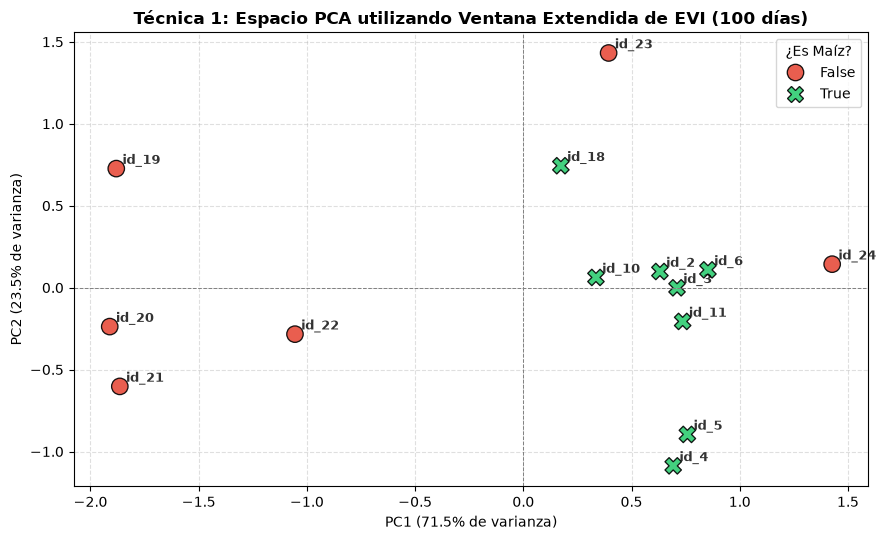

In [18]:
# La matriz de entrada son los 100 días cronológicos puros de EVI
evaluar_y_graficar_pca(
    matriz_caracteristicas=matriz_evi_100, 
    titulo="Técnica 1: Espacio PCA utilizando Ventana Extendida de EVI (100 días)"
)

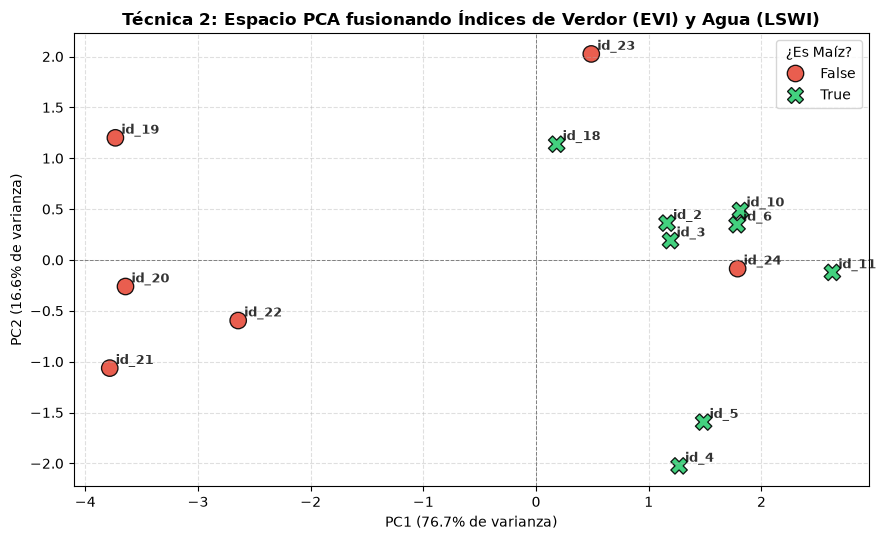

In [19]:
# Combinar horizontalmente las firmas de ambos índices espectrales
matriz_fusionada = np.hstack([matriz_evi_100, matriz_lswi_100])

evaluar_y_graficar_pca(
    matriz_caracteristicas=matriz_fusionada, 
    titulo="Técnica 2: Espacio PCA fusionando Índices de Verdor (EVI) y Agua (LSWI)"
)

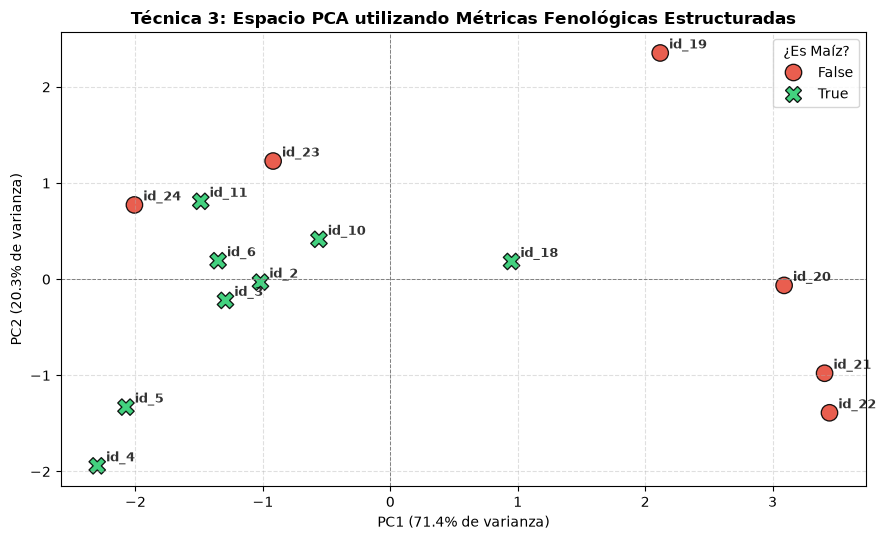

In [20]:
from sklearn.preprocessing import StandardScaler

metricas_fenologicas = []

for i in range(len(matriz_evi_100)):
    curva_e = matriz_evi_100[i]
    curva_l = matriz_lswi_100[i]
    
    # 1. Hitos de Clorofila (EVI)
    max_evi = np.max(curva_e)
    dia_max_evi = np.argmax(curva_e)
    pendiente_asc_evi = (curva_e[30] - curva_e[0]) / 30  # Velocidad de desarrollo inicial
    pendiente_desc_evi = (curva_e[-1] - max_evi) / (100 - dia_max_evi) if dia_max_evi < 99 else 0
    
    # 2. Hitos de Humedad (LSWI)
    max_lswi = np.max(curva_l)
    min_lswi_post_pico = np.min(curva_l[dia_max_evi:]) if dia_max_evi < 99 else curva_l[-1]
    
    metricas_fenologicas.append([
        max_evi, dia_max_evi, pendiente_asc_evi, pendiente_desc_evi, max_lswi, min_lswi_post_pico
    ])

# Convertir y estandarizar amplitudes (Media = 0, Varianza = 1)
matriz_metricas = np.array(metricas_fenologicas)
scaler = StandardScaler()
matriz_metricas_scaled = scaler.fit_transform(matriz_metricas)

evaluar_y_graficar_pca(
    matriz_caracteristicas=matriz_metricas_scaled, 
    titulo="Técnica 3: Espacio PCA utilizando Métricas Fenológicas Estructuradas"
)

In [21]:
def graficar_resultado_pca(componentes, pca_obj, titulo_experimento):
    """Función para estandarizar la visualización de los 3 experimentos"""
    df_plot = pd.DataFrame(componentes, columns=['PC1', 'PC2'])
    df_plot['es_maiz'] = tabla_ciclos_final['es_confirmado_maiz'].values
    df_plot['id_parcela'] = tabla_ciclos_final['id_parcela'].values
    df_plot['subtipo'] = tabla_ciclos_final['subtipo_maiz'].values

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df_plot, x='PC1', y='PC2', hue='es_maiz', style='es_maiz',
        palette={True: '#2ecc71', False: '#e74c3c'}, s=120, alpha=0.8, edgecolor='black'
    )
    
    for i, fila in df_plot.iterrows():
        if fila['es_maiz']:
            plt.text(fila['PC1'] + 0.02, fila['PC2'] + 0.02, f"id_{fila['id_parcela']}", fontsize=9, weight='bold')

    plt.title(titulo_experimento, fontsize=12, weight='bold')
    plt.xlabel(f'PC1 ({pca_obj.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'PC2 ({pca_obj.explained_variance_ratio_[1]*100:.1f}%)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.axhline(0, color='grey', lw=0.8, ls='--')
    plt.axvline(0, color='grey', lw=0.8, ls='--')
    plt.show()

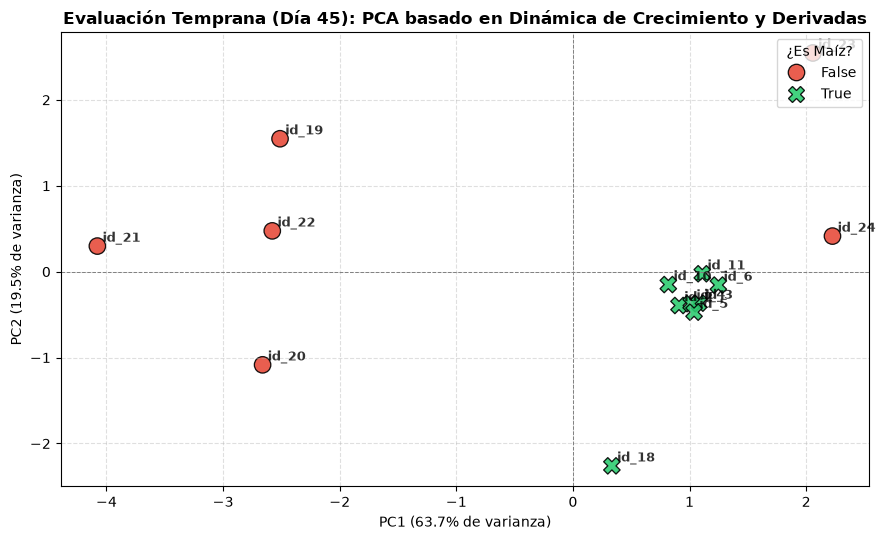

In [22]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Fijamos la ventana estrictamente a 45 días (Clasificación Temprana)
ventana_temprana = 45
metricas_tempranas = []

for i in range(len(matriz_evi_100)):
    # Recortamos las curvas de 100 días a solo los primeros 45 días
    curva_e_temp = matriz_evi_100[i][:ventana_temprana]
    curva_l_temp = matriz_lswi_100[i][:ventana_temprana]
    
    # 1. TASAS DE CAMBIO (Derivadas numéricas)
    # Primera derivada: Velocidad diaria de crecimiento
    velocidad_evi = np.diff(curva_e_temp)
    max_velocidad = np.max(velocidad_evi)
    dia_max_velocidad = np.argmax(velocidad_evi)
    
    # Segunda derivada: Aceleración del crecimiento
    aceleracion_evi = np.diff(velocidad_evi)
    max_aceleracion = np.max(aceleracion_evi)
    
    # 2. HITOS ESTÁTICOS TEMPRANOS
    evi_dia_45 = curva_e_temp[-1]
    lswi_dia_45 = curva_l_temp[-1]
    max_evi_temp = np.max(curva_e_temp)
    
    # 3. INTERACCIÓN MULTIESPECTRAL (Verdor vs Agua)
    # El maíz suele deprimir el LSWI temporalmente a mitad de su crecimiento rápido por alta transpiración
    relacion_evi_lswi_final = evi_dia_45 / (lswi_dia_45 + 0.001)
    coef_correlacion_interna = np.corrcoef(curva_e_temp, curva_l_temp)[0, 1]
    
    # Consolidar el vector de características tempranas
    metricas_tempranas.append([
        max_evi_temp,          # Techo de verdor temprano
        max_velocidad,         # Qué tan rápido despierta el cultivo
        dia_max_velocidad,     # Momento del "subidón" de crecimiento
        max_aceleracion,       # Fuerza del arranque biológico
        relacion_evi_lswi_final, # Balance clorofila/agua al día 45
        coef_correlacion_interna # Sincronía temporal verdor-agua
    ])

# Convertir a matriz y aplicar escalado estándar
matriz_metricas_temp = np.array(metricas_tempranas)
scaler_temp = StandardScaler()
matriz_metricas_temp_scaled = scaler_temp.fit_transform(matriz_metricas_temp)

# Ejecutar el diagnóstico visual con la ventana recortada
evaluar_y_graficar_pca(
    matriz_caracteristicas=matriz_metricas_temp_scaled, 
    titulo="Evaluación Temprana (Día 45): PCA basado en Dinámica de Crecimiento y Derivadas"
)

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# 1. Preparar las variables predictoras (X) y la variable objetivo (y)
# Usamos las métricas escaladas de 45 días que ya demostraron ser infalibles
X = matriz_metricas_temp_scaled
y = df_meta_final['es_maiz'].values  # Contiene True (Maíz) y False (No Maíz)

# 2. Dividir en set de entrenamiento y set de validación
# Nota: Como es una muestra piloto pequeña, dejamos el 20% para test. 
# Cuando proceses los 57 ciclos, esta división será mucho más robusta.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Datos de entrenamiento: {X_train.shape[0]} parcelas")
print(f"Datos de prueba: {X_test.shape[0]} parcelas\n")

# 3. Construir y entrenar el Clasificador (Máquina de Soporte Vectorial Lineal)
# Usamos un kernel lineal porque 'image_df096c.png' nos demostró que la separación es recta
clasificador_maiz = SVC(kernel='linear', C=1.0, random_state=42)
clasificador_maiz.fit(X_train, y_train)

# 4. Evaluar el rendimiento del modelo con los datos de prueba
y_pred = clasificador_maiz.predict(X_test)

print("=== REPORTE DE CLASIFICACIÓN TEMPRANA ===")
print(classification_report(y_test, y_pred))

print("=== MATRIZ DE CONFUSIÓN ===")
print(confusion_matrix(y_test, y_pred))

# 5. GUARDAR EL MODELO ENTRENADO
# Esto te permitirá empaquetarlo y usarlo en tu pipeline automatizado final
joblib.dump(clasificador_maiz, 'clasificador_temprano_maiz.pkl')
joblib.dump(scaler_temp, 'escalador_temprano_maiz.pkl')
print("\n¡Clasificador entrenado y guardado con éxito como 'clasificador_temprano_maiz.pkl'!")

Datos de entrenamiento: 11 parcelas
Datos de prueba: 3 parcelas

=== REPORTE DE CLASIFICACIÓN TEMPRANA ===
              precision    recall  f1-score   support

       False       1.00      1.00      1.00         1
        True       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

=== MATRIZ DE CONFUSIÓN ===
[[1 0]
 [0 2]]

¡Clasificador entrenado y guardado con éxito como 'clasificador_temprano_maiz.pkl'!


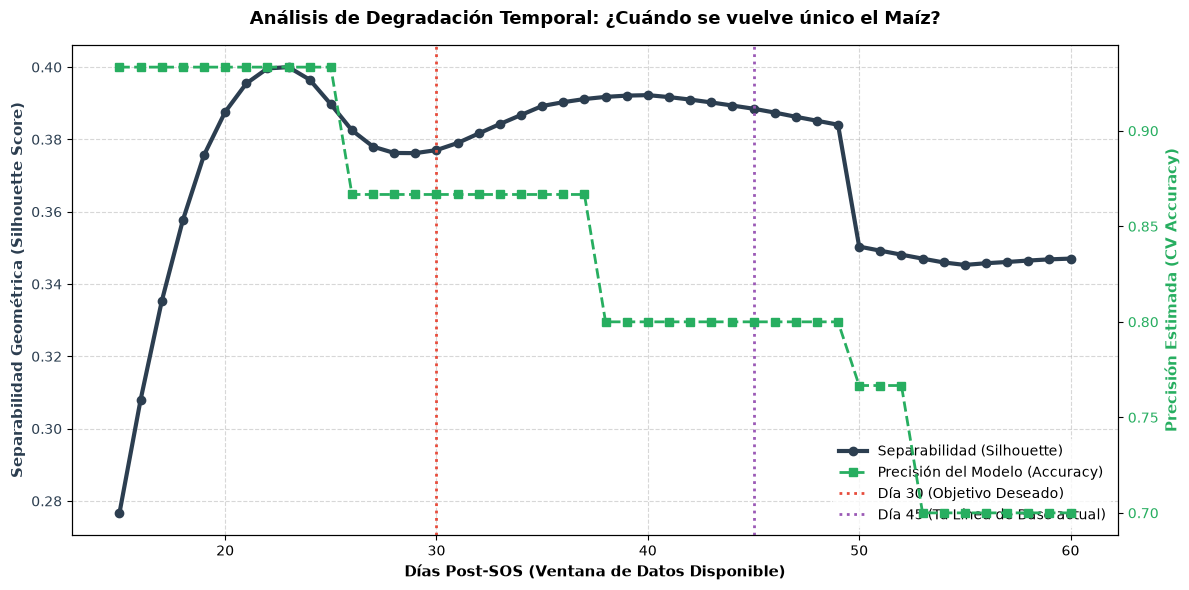

 El día de máxima separabilidad biofísica es el Día: 23 (Score: 0.400)
 En el Día 30, el score de separabilidad es de: 0.377
 Al adelantar la clasificación al Día 30, la separabilidad se degrada un: 5.74%


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.svm import SVC

# 1. FUNCIÓN PARA EXTRAER CARACTERÍSTICAS DINÁMICAS HASTA UN DÍA "T" ESPECÍFICO
def extraer_features_al_dia(matriz_evi, matriz_lswi, dia_corte):
    features_dia = []
    for i in range(len(matriz_evi)):
        # Recortar las series temporales estrictamente desde el día 0 hasta el dia_corte
        curva_e = matriz_evi[i][:dia_corte]
        curva_l = matriz_lswi[i][:dia_corte]
        
        # Derivadas (Velocidad y Aceleración)
        vel_evi = np.diff(curva_e) if len(curva_e) > 1 else [0]
        max_vel = np.max(vel_evi)
        dia_max_vel = np.argmax(vel_evi)
        
        acel_evi = np.diff(vel_evi) if len(vel_evi) > 1 else [0]
        max_acel = np.max(acel_evi)
        
        # Valores estáticos al día de corte
        evi_final = curva_e[-1]
        lswi_final = curva_l[-1]
        max_evi_temp = np.max(curva_e)
        
        # Interacciones multiespectrales
        ratio_evi_lswi = evi_final / (lswi_final + 0.001)
        
        # Correlación (manejar caso de varianza cero de forma segura)
        with np.errstate(divide='ignore', invalid='ignore'):
            cc = np.corrcoef(curva_e, curva_l)[0, 1]
            cc = 0 if np.isnan(cc) else cc
            
        features_dia.append([max_evi_temp, max_vel, dia_max_vel, max_acel, ratio_evi_lswi, cc])
        
    return np.array(features_dia)

# 2. CONFIGURAR EL RANGO DE BÚSQUEDA (Día 15 al 60 Post-SOS)
dias_a_evaluar = range(15, 61)
scores_silueta = []
precision_cross_val = []

y_target = df_meta_final['es_maiz'].values
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 3. BUCLE DÍA A DÍA
for t in dias_a_evaluar:
    # Extraer y escalar variables exclusivas para el día 't'
    X_t = extraer_features_al_dia(matriz_evi_100, matriz_lswi_100, dia_corte=t)
    X_t_scaled = StandardScaler().fit_transform(X_t)
    
    # Métrica 1: Separabilidad Geométrica Pura (Silhouette Score)
    sil_score = silhouette_score(X_t_scaled, y_target)
    scores_silueta.append(sil_score)
    
    # Métrica 2: Capacidad Predictiva (Exactitud por Validación Cruzada usando SVM Lineal)
    clf = SVC(kernel='linear', C=1.0, random_state=42)
    acc_scores = cross_val_score(clf, X_t_scaled, y_target, cv=cv, scoring='accuracy')
    precision_cross_val.append(np.mean(acc_scores))

# 4. GENERAR EL GRÁFICO DE DEGRADACIÓN / OPTIMIZACIÓN TEMPORAL
fig, ax1 = plt.subplots(figsize=(12, 6))

# Curva de Separabilidad Geométrica
color = '#2c3e50'
ax1.set_xlabel('Días Post-SOS (Ventana de Datos Disponible)', fontsize=11, weight='bold')
ax1.set_ylabel('Separabilidad Geométrica (Silhouette Score)', color=color, fontsize=11, weight='bold')
line1 = ax1.plot(dias_a_evaluar, scores_silueta, color=color, lw=3, marker='o', label='Separabilidad (Silhouette)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

# Curva de Precisión del Modelo
ax2 = ax1.twinx()  
color2 = '#27ae60'
ax2.set_ylabel('Precisión Estimada (CV Accuracy)', color=color2, fontsize=11, weight='bold')
line2 = ax2.plot(dias_a_evaluar, precision_cross_val, color=color2, lw=2, linestyle='--', marker='s', label='Precisión del Modelo (Accuracy)')
ax2.tick_params(axis='y', labelcolor=color2)

# Línea guía para el Día 30 (Tu objetivo operativo)
ax1.axvline(x=30, color='#e74c3c', linestyle=':', lw=2, label='Día 30 (Objetivo Deseado)')
ax1.axvline(x=45, color='#9b59b6', linestyle=':', lw=2, label='Día 45 (Tu Línea de Base actual)')

# Consolidar leyendas
lineas = line1 + line2 + [ax1.get_lines()[-2], ax1.get_lines()[-1]]
etiquetas = [l.get_label() for l in lineas]
ax1.legend(lineas, etiquetas, loc='lower right', frameon=True, facecolor='white', edgecolor='none')

plt.title('Análisis de Degradación Temporal: ¿Cuándo se vuelve único el Maíz?', fontsize=13, weight='bold', pad=15)
plt.tight_layout()
plt.show()

# 5. IMPRIMIR REPORTE DE CUANTIZACIÓN PARA EL DÍA 30 VS EL MEJOR DÍA
df_resultados = pd.DataFrame({
    'Día_Post_SOS': list(dias_a_evaluar),
    'Separabilidad_Silhouette': scores_silueta,
    'Accuracy_CV': precision_cross_val
})

mejor_dia = df_resultados.loc[df_resultados['Separabilidad_Silhouette'].idxmax()]['Día_Post_SOS']
sil_30 = df_resultados.loc[df_resultados['Día_Post_SOS'] == 30]['Separabilidad_Silhouette'].values[0]
sil_max = df_resultados.loc[df_resultados['Día_Post_SOS'] == mejor_dia]['Separabilidad_Silhouette'].values[0]
degradacion = ((sil_max - sil_30) / sil_max) * 100

print("=====================================================================")
print(f" El día de máxima separabilidad biofísica es el Día: {int(mejor_dia)} (Score: {sil_max:.3f})")
print(f" En el Día 30, el score de separabilidad es de: {sil_30:.3f}")
print(f" Al adelantar la clasificación al Día 30, la separabilidad se degrada un: {degradacion:.2f}%")
print("=====================================================================")

In [25]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import mahalanobis
from scipy.stats import pearsonr, chi2

# =====================================================================
# 1. CONSTRUIR EL PERFIL MAESTRO DE MAÍZ (ESTADÍSTICA DE REFERENCIA)
# =====================================================================
# Filtramos solo los índices de las parcelas que sabemos con certeza que son maíz
indices_maiz_puro = df_meta_final[df_meta_final['es_maiz'] == True].index.tolist()

# Curva cruda promedio de EVI (Día 0 al 30) para el perfil visual de referencia
curvas_maiz_30 = matriz_evi_100[indices_maiz_puro, :30]
perfil_maestro_evi = np.mean(curvas_maiz_30, axis=0)
desv_maestra_evi = np.std(curvas_maiz_30, axis=0)

# Características dinámicas escaladas de las parcelas de maíz (Nuestras 6 métricas)
features_maiz_puro = matriz_metricas_temp_scaled[indices_maiz_puro]

# Calcular el centroide (media) y la matriz de covarianza inversa del maíz
centroide_maiz = np.mean(features_maiz_puro, axis=0)
matriz_covarianza = np.cov(features_maiz_puro, rowvar=False)
# Añadimos una mínima regularización (Ridge) por si la muestra es pequeña y evitar matrices singulares
matriz_cov_inv = np.linalg.inv(matriz_covarianza + np.eye(matriz_covarianza.shape[0]) * 1e-4)

In [26]:
def evaluar_similitud_parcela(id_p, dia_corte=30):
    """
    Evalúa la similitud de una parcela usando directamente su ID numérico real.
    Ejemplo: id_p = 19 para la parcela 'id_19'
    """
    # 1. Encontrar automáticamente la posición posicional (fila) que le corresponde a ese ID
    coincidencias = df_meta_final[df_meta_final['id_parcela'] == id_p].index
    
    if len(coincidencias) == 0:
        print(f"❌ Error: La parcela 'id_{id_p}' no se encuentra en tus metadatos indexados.")
        print(f"IDs que sí tienes disponibles para probar: {df_meta_final['id_parcela'].tolist()}")
        return
        
    # Extraemos el índice posicional real de Python
    id_index = coincidencias[0]
    
    # 2. Extraer datos de las matrices usando el índice posicional encontrado
    curva_evaluar = matriz_evi_100[id_index, :dia_corte]
    features_evaluar = matriz_metricas_temp_scaled[id_index]
    es_realmente_maiz = df_meta_final.loc[id_index, 'es_maiz']
    
    # 3. Métrica A: Distancia de Mahalanobis
    dist_mah = mahalanobis(features_evaluar, centroide_maiz, matriz_cov_inv)
    p_valor = 1.0 - chi2.cdf(dist_mah**2, df=6)
    score_mahalanobis = p_valor * 100  
    
    # 4. Métrica B: Correlación de Pearson 
    r_pearson, _ = pearsonr(curva_evaluar, perfil_maestro_evi)
    
    # 5. Métrica C: RMSE
    rmse = np.sqrt(np.mean((curva_evaluar - perfil_maestro_evi)**2))
    
    # --- Reporte para el Operador ---
    print(f"=== REPORTE DE DECISIÓN: PARCELA id_{id_p} (Evaluada al Día {dia_corte}) ===")
    print(f"• Verdad de Campo Histórica : {'MAÍZ' if es_realmente_maiz else 'NO MAÍZ'}")
    print(f"• Sincronía de Forma (Pearson r) : {r_pearson:.3f} (Ideal > 0.85)")
    print(f"• Desviación de Magnitud (RMSE)  : {rmse:.4f} EVI")
    print(f"• Proximidad Estadística Coherente: {score_mahalanobis:.1f}%")
    
    if score_mahalanobis > 50 and r_pearson > 0.85:
        print(" 🟢 PREDICTOR SUGIERE: Comportamiento Altamente Coherente con Maíz.")
    elif score_mahalanobis > 15 or r_pearson > 0.70:
        print(" ⚠️ PREDICTOR SUGIERE: Comportamiento Dudoso. Requiere inspección visual de curvas.")
    else:
        print(" ❌ PREDICTOR SUGIERE: Desviación Crítica. Altamente probable que NO sea Maíz.")
    print("-" * 65)

In [27]:
print("PROBANDO UN MAÍZ REAL HOMOGÉNEO:")
evaluar_similitud_parcela(id_p=3, dia_corte=30) 

print("\nPROBANDO UNA PARCELA DE CONTROL (NO MAÍZ):")
# id_19 es un False confirmado en tus gráficas previas
evaluar_similitud_parcela(id_p=24, dia_corte=30)

PROBANDO UN MAÍZ REAL HOMOGÉNEO:
=== REPORTE DE DECISIÓN: PARCELA id_3 (Evaluada al Día 30) ===
• Verdad de Campo Histórica : MAÍZ
• Sincronía de Forma (Pearson r) : 1.000 (Ideal > 0.85)
• Desviación de Magnitud (RMSE)  : 0.0206 EVI
• Proximidad Estadística Coherente: 87.6%
 🟢 PREDICTOR SUGIERE: Comportamiento Altamente Coherente con Maíz.
-----------------------------------------------------------------

PROBANDO UNA PARCELA DE CONTROL (NO MAÍZ):
=== REPORTE DE DECISIÓN: PARCELA id_24 (Evaluada al Día 30) ===
• Verdad de Campo Histórica : NO MAÍZ
• Sincronía de Forma (Pearson r) : 1.000 (Ideal > 0.85)
• Desviación de Magnitud (RMSE)  : 0.0833 EVI
• Proximidad Estadística Coherente: 0.0%
 ⚠️ PREDICTOR SUGIERE: Comportamiento Dudoso. Requiere inspección visual de curvas.
-----------------------------------------------------------------


In [28]:
# Celda 1: preparar datos y perfil maestro
import numpy as np
import pandas as pd

# --- REEMPLAZA estas variables por tus objetos reales si tienen otros nombres ---
# df_meta_final: DataFrame con columna 'es_maiz' booleana
# matriz_evi_100: array (n_parcelas, n_días) con EVI
# matriz_metricas_temp_scaled: array (n_parcelas, n_features) con 6 métricas ya escaladas

# Ejemplo de comprobación mínima
print("df_meta_final shape:", df_meta_final.shape)
print("matriz_evi_100 shape:", matriz_evi_100.shape)
print("matriz_metricas_temp_scaled shape:", matriz_metricas_temp_scaled.shape)

# Índices de maíz puro
indices_maiz_puro = df_meta_final[df_meta_final['es_maiz'] == True].index.tolist()

# Perfil maestro EVI (día 0 a 30)
curvas_maiz_30 = matriz_evi_100[indices_maiz_puro, :30]
perfil_maestro_evi = np.mean(curvas_maiz_30, axis=0)
desv_maestra_evi = np.std(curvas_maiz_30, axis=0)

# Features escaladas (6 métricas)
features_maiz_puro = matriz_metricas_temp_scaled[indices_maiz_puro]

# Centroide y covarianza empírica
centroide_maiz = np.mean(features_maiz_puro, axis=0)
matriz_covarianza = np.cov(features_maiz_puro, rowvar=False)

# Regularización mínima por defecto
epsilon_default = 1e-4
matriz_cov_inv = np.linalg.inv(matriz_covarianza + np.eye(matriz_covarianza.shape[0]) * epsilon_default)

print("Centroide (maíz):", centroide_maiz)
print("Covarianza shape:", matriz_covarianza.shape)


df_meta_final shape: (14, 3)
matriz_evi_100 shape: (14, 100)
matriz_metricas_temp_scaled shape: (14, 6)
Centroide (maíz): [ 0.49061091  0.34125597 -0.67639603  0.06325697  0.51522024  0.28810783]
Covarianza shape: (6, 6)


In [29]:
# Celda 2: funciones para Mahalanobis y evaluación
import numpy as np
from scipy.spatial.distance import mahalanobis
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc, confusion_matrix

def mahalanobis_distances(X, centroide, cov_inv):
    """
    X: array (n_samples, n_features)
    centroide: array (n_features,)
    cov_inv: inversa de la matriz de covarianza (n_features, n_features)
    Devuelve: vector de distancias Mahalanobis
    """
    dif = X - centroide
    # cálculo vectorizado: d_i^2 = (x-mu) @ cov_inv @ (x-mu).T
    left = dif @ cov_inv
    d2 = np.sum(left * dif, axis=1)
    return np.sqrt(np.maximum(d2, 0.0))

def evaluar_distancias(distancias, etiquetas_true):
    """
    distancias: array (n_samples,) — cuanto menor, más parecido a maíz
    etiquetas_true: boolean o 0/1 (1 = maíz)
    Devuelve: diccionario con AUC, curva ROC y PR
    """
    # Convertir a score donde mayor = más probabilidad de ser maíz
    # Si distancia baja => más parecido => score = -distancia
    scores = -distancias
    auc_roc = roc_auc_score(etiquetas_true, scores)
    fpr, tpr, thr_roc = roc_curve(etiquetas_true, scores)
    precision, recall, thr_pr = precision_recall_curve(etiquetas_true, scores)
    auc_pr = auc(recall, precision)
    return {
        "auc_roc": auc_roc,
        "auc_pr": auc_pr,
        "roc_curve": (fpr, tpr, thr_roc),
        "pr_curve": (precision, recall, thr_pr),
        "scores": scores
    }

# Ejemplo de uso con la inversa calculada antes:
X_all = matriz_metricas_temp_scaled  # todas las parcelas
dist_all = mahalanobis_distances(X_all, centroide_maiz, matriz_cov_inv)
etiquetas = df_meta_final['es_maiz'].astype(int).values
res_eval = evaluar_distancias(dist_all, etiquetas)
print("AUC ROC (cov empírica):", res_eval["auc_roc"])
print("AUC PR (cov empírica):", res_eval["auc_pr"])


AUC ROC (cov empírica): 1.0
AUC PR (cov empírica): 1.0


In [30]:
# Celda 1: Leave-One-Out Mahalanobis con tres estimadores de covarianza
import numpy as np
import pandas as pd
from sklearn.covariance import LedoitWolf, MinCovDet
from sklearn.metrics import roc_auc_score
import warnings

X = matriz_metricas_temp_scaled.copy()   # (14,6)
y = df_meta_final['es_maiz'].astype(int).values
n, p = X.shape

def mahalanobis_vec(x, mu, cov_inv):
    d = x - mu
    return np.sqrt(np.maximum(d @ cov_inv @ d.T, 0.0))

# Función LOOCV que devuelve scores (neg. distancia) para cada estimador
def loocv_mahalanobis(X, y, estimator='empirical', epsilon=1e-8):
    scores = np.zeros(X.shape[0])
    for i in range(X.shape[0]):
        # entrenamiento sin i
        X_train = np.delete(X, i, axis=0)
        # centroide entrenado
        mu = X_train.mean(axis=0)
        # estimador de covarianza
        if estimator == 'empirical':
            cov = np.cov(X_train, rowvar=False)
        elif estimator == 'ledoit':
            cov = LedoitWolf().fit(X_train).covariance_
        elif estimator == 'mcd':
            try:
                cov = MinCovDet().fit(X_train).covariance_
            except Exception as e:
                # fallback a empírica si MCD falla
                cov = np.cov(X_train, rowvar=False)
        else:
            raise ValueError("estimator must be 'empirical','ledoit' or 'mcd'")
        cov_inv = np.linalg.inv(cov + np.eye(cov.shape[0]) * epsilon)
        d = mahalanobis_vec(X[i], mu, cov_inv)
        scores[i] = -d   # score: mayor = más parecido a maíz
    return scores

estimadores = ['empirical', 'ledoit', 'mcd']
results_loocv = {}
for est in estimadores:
    sc = loocv_mahalanobis(X, y, estimator=est, epsilon=1e-8)
    auc = roc_auc_score(y, sc)
    results_loocv[est] = {'scores': sc, 'auc': auc}
    print(f"LOOCV {est}: AUC ROC = {auc:.4f}")

# Mostrar scores por muestra
df_scores = pd.DataFrame({k: v['scores'] for k,v in results_loocv.items()})
df_scores['y'] = y
print("\nScores LOOCV (primeras filas):")
print(df_scores.head(10))


LOOCV empirical: AUC ROC = 0.8750
LOOCV ledoit: AUC ROC = 0.9167
LOOCV mcd: AUC ROC = 0.5833

Scores LOOCV (primeras filas):
   empirical    ledoit         mcd  y
0  -2.199226 -0.789016 -128.291497  1
1  -1.964262 -0.857960 -124.030749  1
2  -1.333937 -0.809096  -90.450519  1
3  -1.199584 -0.903635  -92.617058  1
4  -0.929458 -0.882680  -90.425748  1
5  -1.756307 -0.642095 -108.671325  1
6  -1.940469 -0.939525  -90.527026  1
7 -18.271707 -3.585872 -137.771065  1
8  -6.207468 -3.406531 -105.853793  0
9  -5.556114 -2.846925 -122.945693  0


Permutations:   0%|          | 0/500 [00:00<?, ?it/s]

Permutations: 100%|██████████| 500/500 [00:03<00:00, 158.80it/s]


Real LOOCV AUC (Ledoit): 0.9167
P-value (permutaciones): 0.0080


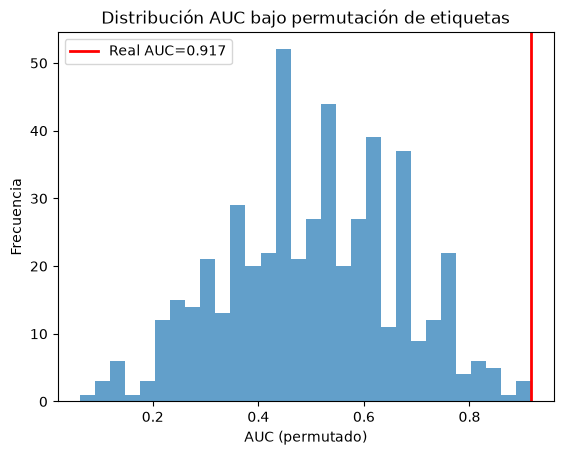

In [31]:
# Celda 2: prueba de permutación para AUC (1000 permutaciones por defecto)
import numpy as np
from tqdm import trange
from sklearn.metrics import roc_auc_score
rng = np.random.default_rng(42)

def permutation_test_auc(X, y, estimator='ledoit', n_perm=1000):
    # AUC real (LOOCV)
    real_scores = loocv_mahalanobis(X, y, estimator=estimator)
    real_auc = roc_auc_score(y, real_scores)
    perm_aucs = np.zeros(n_perm)
    for k in trange(n_perm, desc="Permutations"):
        y_perm = rng.permutation(y)
        perm_scores = loocv_mahalanobis(X, y_perm, estimator=estimator)
        perm_aucs[k] = roc_auc_score(y_perm, perm_scores)
    p_value = (np.sum(perm_aucs >= real_auc) + 1) / (n_perm + 1)
    return real_auc, perm_aucs, p_value

# Ejecutar (puedes reducir n_perm si es lento)
real_auc, perm_aucs, pval = permutation_test_auc(X, y, estimator='ledoit', n_perm=500)
print(f"Real LOOCV AUC (Ledoit): {real_auc:.4f}")
print(f"P-value (permutaciones): {pval:.4f}")

# Resumen rápido
import matplotlib.pyplot as plt
plt.hist(perm_aucs, bins=30, alpha=0.7)
plt.axvline(real_auc, color='red', lw=2, label=f"Real AUC={real_auc:.3f}")
plt.xlabel("AUC (permutado)")
plt.ylabel("Frecuencia")
plt.title("Distribución AUC bajo permutación de etiquetas")
plt.legend()
plt.savefig("prueba_permutacion_auc.pdf", format="pdf", bbox_inches="tight")
plt.show()


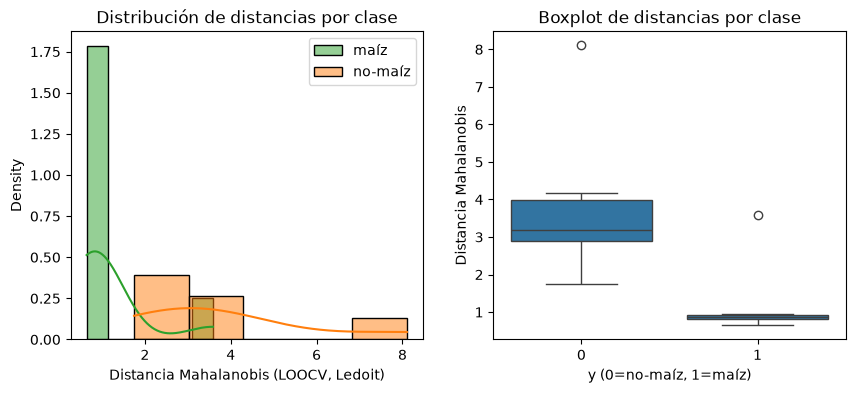

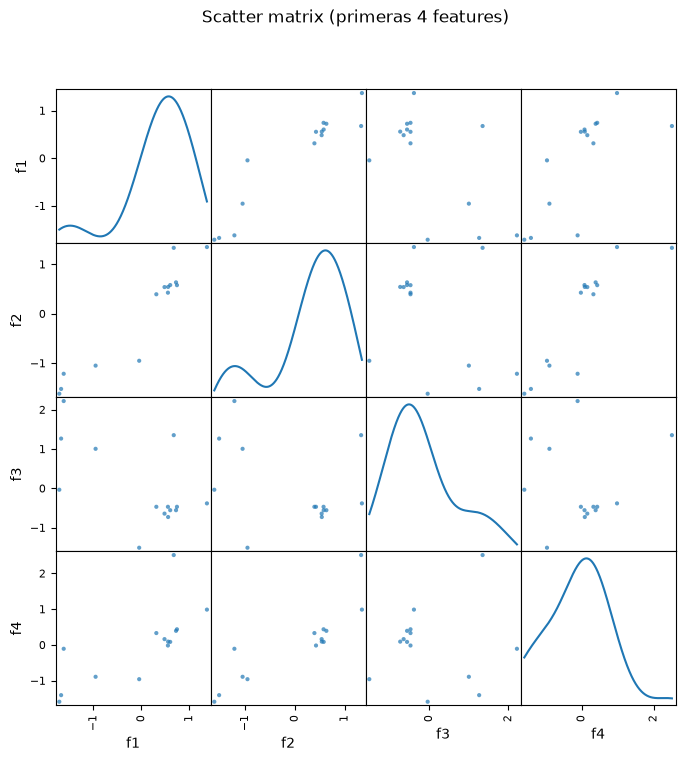

In [32]:
# Celda 3: histogramas y boxplots de distancias LOOCV (Ledoit) y scatter matrix parcial
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

# Usar Ledoit como ejemplo (puedes cambiar)
scores_ledoit = results_loocv['ledoit']['scores']
# Distancias reales (positivas) = -scores
dist_ledoit = -scores_ledoit

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(dist_ledoit[y==1], color='tab:green', label='maíz', kde=True, stat='density')
sns.histplot(dist_ledoit[y==0], color='tab:orange', label='no-maíz', kde=True, stat='density')
plt.legend()
plt.xlabel("Distancia Mahalanobis (LOOCV, Ledoit)")
plt.title("Distribución de distancias por clase")

plt.subplot(1,2,2)
sns.boxplot(x=y, y=dist_ledoit)
plt.xlabel("y (0=no-maíz, 1=maíz)")
plt.ylabel("Distancia Mahalanobis")
plt.title("Boxplot de distancias por clase")
plt.show()

# Scatter matrix de las primeras 4 features (para evitar demasiados paneles)
df_feats = pd.DataFrame(X, columns=[f"f{i+1}" for i in range(X.shape[1])])
df_feats['y'] = y
scatter_matrix(df_feats.iloc[:, :4], figsize=(8,8), diagonal='kde', alpha=0.7)
plt.suptitle("Scatter matrix (primeras 4 features)")
plt.show()


In [33]:
# Celda 4: correlación entre features y etiqueta; revisar valores extremos
import pandas as pd
df_feats = pd.DataFrame(X, columns=[f"f{i+1}" for i in range(X.shape[1])])
df_feats['y'] = y

# Correlación (Pearson) entre cada feature y la etiqueta
corrs = df_feats.corr()['y'].drop('y').sort_values(key=lambda s: s.abs(), ascending=False)
print("Correlación (feature vs etiqueta):")
print(corrs)

# Mostrar valores por clase para detectar fugas o valores triviales
for col in df_feats.columns[:-1]:
    print(f"\nFeature {col} — resumen por clase:")
    print(df_feats.groupby('y')[col].describe())


Correlación (feature vs etiqueta):
f3   -0.781035
f5    0.594925
f1    0.566509
f2    0.394048
f6    0.332678
f4    0.073043
Name: y, dtype: float64

Feature f1 — resumen por clase:
   count      mean       std       min       25%       50%       75%       max
y                                                                             
0    6.0 -0.654148  1.345268 -1.713621 -1.662419 -1.289024  0.267236  1.367676
1    8.0  0.490611  0.255852 -0.046345  0.439751  0.555671  0.631479  0.742179

Feature f2 — resumen por clase:
   count      mean       std       min       25%       50%       75%       max
y                                                                             
0    6.0 -0.455008  1.404775 -1.619309 -1.445756 -1.133306  0.735669  1.347120
1    8.0  0.341256  0.529041 -0.952836  0.416308  0.539259  0.576897  0.632778

Feature f3 — resumen por clase:
   count      mean       std       min       25%       50%       75%       max
y                                        

## Clasificador Ledoit-Wolf

In [34]:
from sklearn.covariance import LedoitWolf

indices_maiz_puro = df_meta_final[df_meta_final['es_maiz'] == True].index.tolist()
features_maiz_puro = matriz_metricas_temp_scaled[indices_maiz_puro]

lw = LedoitWolf().fit(features_maiz_puro)
centroide_maiz = lw.location_          # equivalente a la media, pero calculado por el propio estimador
matriz_cov_inv = lw.precision_         # ya es la inversa (matriz de precisión), no hace falta invertir manualmente

print(f"Shrinkage aplicado: {lw.shrinkage_:.4f}")  # 0 = sin shrinkage (covarianza empírica pura), 1 = shrinkage total

Shrinkage aplicado: 0.7332


In [35]:
def calcular_features_para_dia(dia_corte, indices=None):
    """Recalcula las 6 métricas dinámicas truncando estrictamente a dia_corte."""
    X = extraer_features_al_dia(matriz_evi_100, matriz_lswi_100, dia_corte=dia_corte)
    if indices is not None:
        X = X[indices]
    return X

In [36]:
def construir_perfil_maiz(dia_corte, indices_maiz):
    X_maiz = calcular_features_para_dia(dia_corte, indices_maiz)
    scaler = StandardScaler().fit(X_maiz)
    X_maiz_scaled = scaler.transform(X_maiz)
    lw = LedoitWolf().fit(X_maiz_scaled)
    return scaler, lw

# Uno por cada ventana operativa
perfil_t1 = construir_perfil_maiz(30, indices_maiz_puro)
perfil_t2 = construir_perfil_maiz(42, indices_maiz_puro)
perfil_t3 = construir_perfil_maiz(60, indices_maiz_puro)

In [37]:
# Celda — Definir índices de maíz y no-maíz, y chequeo rápido de f6

indices_maiz_puro = df_meta_final[df_meta_final['es_maiz'] == True].index.tolist()
indices_no_maiz = df_meta_final[df_meta_final['es_maiz'] == False].index.tolist()

print(f"Maíz confirmado: {len(indices_maiz_puro)} parcelas -> {df_meta_final.loc[indices_maiz_puro, 'id_parcela'].tolist()}")
print(f"No-maíz confirmado: {len(indices_no_maiz)} parcelas -> {df_meta_final.loc[indices_no_maiz, 'id_parcela'].tolist()}")

# --- Chequeo de f6 (coef_correlacion_interna EVI-LSWI) ---
# Usamos la matriz ya calculada a 45 días como referencia rápida de diagnóstico
f6_maiz = matriz_metricas_temp_scaled[indices_maiz_puro, 5]
f6_no_maiz = matriz_metricas_temp_scaled[indices_no_maiz, 5]

# También en escala original (sin estandarizar) para ver el coeficiente de correlación real, más interpretable
f6_maiz_crudo = matriz_metricas_temp[indices_maiz_puro, 5]
f6_no_maiz_crudo = matriz_metricas_temp[indices_no_maiz, 5]

print("\n=== f6 (correlación interna EVI-LSWI) — valores crudos (sin escalar) ===")
for idx, val in zip(indices_maiz_puro, f6_maiz_crudo):
    print(f"  MAÍZ    id_{df_meta_final.loc[idx, 'id_parcela']}: {val:.4f}")
for idx, val in zip(indices_no_maiz, f6_no_maiz_crudo):
    print(f"  NO-MAÍZ id_{df_meta_final.loc[idx, 'id_parcela']}: {val:.4f}")

print(f"\nMaíz    -> media={f6_maiz_crudo.mean():.4f}  std={f6_maiz_crudo.std():.4f}  min={f6_maiz_crudo.min():.4f}  max={f6_maiz_crudo.max():.4f}")
print(f"No-maíz -> media={f6_no_maiz_crudo.mean():.4f}  std={f6_no_maiz_crudo.std():.4f}  min={f6_no_maiz_crudo.min():.4f}  max={f6_no_maiz_crudo.max():.4f}")

# Señal de alarma: valores exactos en el límite (-1.0, 1.0, o repetidos exactos) sugieren bug de cálculo,
# no señal fisiológica real
sospechosos = np.concatenate([f6_maiz_crudo, f6_no_maiz_crudo])
if np.any(np.isclose(np.abs(sospechosos), 1.0, atol=1e-6)):
    print("\n⚠️ Hay valores de f6 exactamente en ±1.0 — revisar si alguna curva tiene varianza cero "
          "(np.corrcoef con serie constante da resultados degenerados, no error, pero sí sospechoso).")
if len(np.unique(np.round(f6_maiz_crudo, 6))) < len(f6_maiz_crudo):
    print("⚠️ Hay valores de f6 duplicados exactos dentro de maíz — revisar si hay parcelas con series idénticas "
          "(posible bug de indexación, ej. dos IDs apuntando a la misma columna).")

Maíz confirmado: 8 parcelas -> [2, 3, 4, 5, 6, 10, 11, 18]
No-maíz confirmado: 6 parcelas -> [19, 20, 21, 22, 23, 24]

=== f6 (correlación interna EVI-LSWI) — valores crudos (sin escalar) ===
  MAÍZ    id_2: 0.9968
  MAÍZ    id_3: 0.9944
  MAÍZ    id_4: 0.9975
  MAÍZ    id_5: 0.9981
  MAÍZ    id_6: 0.9984
  MAÍZ    id_10: 0.9967
  MAÍZ    id_11: 0.9991
  MAÍZ    id_18: 0.9998
  NO-MAÍZ id_19: 0.9921
  NO-MAÍZ id_20: 0.9952
  NO-MAÍZ id_21: -0.2249
  NO-MAÍZ id_22: 0.9564
  NO-MAÍZ id_23: 0.9999
  NO-MAÍZ id_24: 0.9999

Maíz    -> media=0.9976  std=0.0016  min=0.9944  max=0.9998
No-maíz -> media=0.7864  std=0.4525  min=-0.2249  max=0.9999


In [38]:
# Celda — LOOCV honesto con Ledoit-Wolf, parametrizado por dia_corte (T1=30, T2=42, T3=60)

from sklearn.covariance import LedoitWolf
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import mahalanobis
from sklearn.metrics import roc_auc_score

def calcular_features_para_dia(dia_corte, indices=None):
    """Recalcula las 6 métricas dinámicas truncando estrictamente a dia_corte (sin look-ahead)."""
    X = extraer_features_al_dia(matriz_evi_100, matriz_lswi_100, dia_corte=dia_corte)
    if indices is not None:
        X = X[indices]
    return X

def loocv_auc_ledoit(dia_corte, indices_maiz, indices_no_maiz):
    """
    LOOCV real: en cada iteración se re-ajustan scaler + Ledoit-Wolf usando solo
    las parcelas de maíz restantes (excluyendo la dejada fuera, si es maíz).
    Los no-maíz siempre se evalúan como negativos, nunca entran al perfil de referencia.
    """
    todos_indices = indices_maiz + indices_no_maiz
    y_true, y_score, detalle = [], [], []

    for idx_out in todos_indices:
        es_maiz_out = idx_out in indices_maiz
        indices_maiz_fold = [i for i in indices_maiz if i != idx_out]

        X_maiz_fold = calcular_features_para_dia(dia_corte, indices_maiz_fold)
        scaler = StandardScaler().fit(X_maiz_fold)
        X_maiz_scaled = scaler.transform(X_maiz_fold)

        lw = LedoitWolf().fit(X_maiz_scaled)

        x_out = calcular_features_para_dia(dia_corte, [idx_out])
        x_out_scaled = scaler.transform(x_out)
        dist = mahalanobis(x_out_scaled[0], lw.location_, lw.precision_)

        y_true.append(1 if es_maiz_out else 0)
        y_score.append(-dist)  # score = -distancia (mayor score = más parecido a maíz)
        detalle.append({
            "id_parcela": df_meta_final.loc[idx_out, "id_parcela"],
            "es_maiz_real": es_maiz_out,
            "distancia_mahalanobis": dist,
            "shrinkage": lw.shrinkage_,
        })

    auc = roc_auc_score(y_true, y_score)
    return auc, pd.DataFrame(detalle)


LOOCV_DIAS = [25, 30, 42, 60]
resumen_auc = []

for t in LOOCV_DIAS:
    auc, df_detalle = loocv_auc_ledoit(t, indices_maiz_puro, indices_no_maiz)
    resumen_auc.append({"dia": t, "auc_loocv": auc})
    print(f"\n=== Día {t} — AUC LOOCV (Ledoit-Wolf): {auc:.4f} ===")
    print(df_detalle.sort_values("distancia_mahalanobis").to_string(index=False))

df_resumen_auc = pd.DataFrame(resumen_auc)
print("\n\n=== Resumen AUC por ventana operativa ===")
print(df_resumen_auc.to_string(index=False))


=== Día 25 — AUC LOOCV (Ledoit-Wolf): 0.9375 ===
 id_parcela  es_maiz_real  distancia_mahalanobis  shrinkage
          4          True               0.759522   0.716900
          5          True               0.945008   0.725095
          2          True               1.248276   0.723095
          6          True               1.388680   0.726920
          3          True               2.001036   0.710834
         10          True               2.512464   0.725805
         11          True               3.034892   0.722741
         24         False               4.394835   0.766237
         19         False              13.567079   0.766237
         20         False              14.471477   0.766237
         18          True              25.762749   0.585688
         23         False             120.239513   0.766237
         22         False             810.870398   0.766237
         21         False            2376.735266   0.766237

=== Día 30 — AUC LOOCV (Ledoit-Wolf): 0.9167 ===


In [39]:
# Celda — Graficar EVI y LSWI de id_21 (y contraste rápido con un maíz típico y otro no-maíz "fácil")

import plotly.graph_objects as go
from plotly.subplots import make_subplots

def graficar_evi_lswi(id_p, ventana=60):
    fila = df_meta_final[df_meta_final['id_parcela'] == id_p]
    if fila.empty:
        print(f"❌ id_{id_p} no encontrado en df_meta_final")
        return
    idx = fila.index[0]

    serie_evi = matriz_evi_100[idx, :ventana + 1]
    serie_lswi = matriz_lswi_100[idx, :ventana + 1]
    dias = np.arange(ventana + 1)

    fig = make_subplots(specs=[[{"secondary_y": True}]])
    fig.add_trace(go.Scatter(x=dias, y=serie_evi, mode="lines", name="EVI",
                              line=dict(color="green", width=2)), secondary_y=False)
    fig.add_trace(go.Scatter(x=dias, y=serie_lswi, mode="lines", name="LSWI",
                              line=dict(color="blue", width=2)), secondary_y=True)

    es_maiz = fila['es_maiz'].iloc[0]
    fig.update_layout(
        title=f"id_{id_p} — EVI vs LSWI (es_maiz={es_maiz})",
        xaxis_title="Días desde SOS", height=400,
        legend=dict(orientation="h", yanchor="bottom", y=-0.25)
    )
    fig.update_yaxes(title_text="EVI", secondary_y=False)
    fig.update_yaxes(title_text="LSWI", secondary_y=True)
    fig.show()

    # Correlación cruda, para contrastar contra lo ya calculado
    r = np.corrcoef(serie_evi, serie_lswi)[0, 1]
    print(f"id_{id_p}: correlación EVI-LSWI (0-{ventana} días) = {r:.4f}")
    print(f"  EVI  -> min={serie_evi.min():.4f} max={serie_evi.max():.4f}")
    print(f"  LSWI -> min={serie_lswi.min():.4f} max={serie_lswi.max():.4f}")

# El caso a investigar
graficar_evi_lswi(21)

# Contraste: un maíz "típico" (baja distancia Mahalanobis en el LOOCV, ej. id_4) y
# un no-maíz "fácil" de separar (ej. id_22, alta distancia y comportamiento normal de f6)
graficar_evi_lswi(4)
graficar_evi_lswi(22)

id_21: correlación EVI-LSWI (0-60 días) = 0.4372
  EVI  -> min=0.1388 max=0.1810
  LSWI -> min=-0.2716 max=-0.2512


id_4: correlación EVI-LSWI (0-60 días) = 0.9926
  EVI  -> min=0.2427 max=0.5232
  LSWI -> min=-0.1455 max=0.4003


id_22: correlación EVI-LSWI (0-60 días) = 0.9734
  EVI  -> min=0.2047 max=0.2984
  LSWI -> min=-0.2216 max=-0.1109


## Funciones Finales de Producción

In [40]:
def extraer_features_al_dia(matriz_evi, matriz_lswi, dia_corte, indices=None):
    """
    Calcula 6 métricas fenológicas dinámicas para cada serie de una matriz EVI/LSWI,
    truncando estrictamente la información al rango [0, dia_corte] (sin look-ahead).

    NOTA: esta versión NO acota la ventana de cálculo de velocidad/aceleración -- las
    derivadas se calculan sobre toda la ventana [0, dia_corte]. Es consistente con los
    perfiles ya persistidos en `perfil_tipicidad_maiz` (version=1, días 20-60) y con
    el LOOCV que validó T1=30 (AUC 0.9167) y T2=60 (AUC 0.8958).
    Se observó degradación de desempeño en día 90 (T3, AUC 0.75) atribuible a esta
    falta de acotamiento -- ver TODO más abajo. T3 queda fuera de alcance por ahora;
    la corrección (capar a una ventana de crecimiento activo, ej. dia_max_verdeo=35)
    queda como trabajo futuro antes de habilitar T3 en producción.

    Parameters
    ----------
    matriz_evi : np.ndarray, shape (n_parcelas, n_dias)
        Serie EVI diaria por parcela, alineada a SOS (columna 0 = día 0 post-SOS).
    matriz_lswi : np.ndarray, shape (n_parcelas, n_dias)
        Serie LSWI diaria por parcela, misma alineación que matriz_evi.
    dia_corte : int
        Día post-SOS (inclusive) hasta el cual se permite usar información. Las métricas
        nunca usan datos posteriores a este día.
    indices : list[int] o None, default None
        Si se especifica, solo calcula features para esas filas (posiciones) de la matriz
        -- uso recomendado en producción para evaluar una sola parcela nueva sin recalcular
        sobre la matriz completa. Si None, calcula para todas las filas (uso exploratorio).

    Returns
    -------
    np.ndarray, shape (n_parcelas_evaluadas, 6)
        Columnas en este orden:
        0. max_evi_temp            -- techo de verdor alcanzado hasta dia_corte
        1. max_velocidad            -- máxima tasa de cambio diaria de EVI, sobre toda
                                        la ventana [0, dia_corte]
        2. dia_max_velocidad        -- día (índice) donde ocurre esa velocidad máxima
        3. max_aceleracion          -- máxima segunda derivada de EVI, misma ventana
        4. relacion_evi_lswi_final  -- razón EVI/LSWI en el último día disponible (dia_corte)
        5. coef_correlacion_interna -- correlación EVI-LSWI sobre toda la serie [0, dia_corte]
                                        (0.0 si la varianza de alguna serie es cero o hay NaN)

    Notes
    -----
    Filas con NaN en cualquier punto de la ventana devuelven np.nan en las 6 columnas --
    el llamador debe verificar `np.isnan(...).any()` antes de usar el resultado (ej. antes
    de pasarlo a mahalanobis), en vez de asumir que siempre hay un número válido.

    TODO (trabajo futuro): acotar velocidad/aceleración a una ventana de crecimiento
    activo (ej. dia_max_verdeo≈35) para habilitar T3=90 sin degradación de AUC. Requiere
    regenerar los perfiles de referencia y re-correr LOOCV antes de usarse en producción.
    """
    filas = range(len(matriz_evi)) if indices is None else indices
    features_dia = []

    for i in filas:
        curva_e = matriz_evi[i][:dia_corte]
        curva_l = matriz_lswi[i][:dia_corte]

        if np.isnan(curva_e).any() or np.isnan(curva_l).any():
            features_dia.append([np.nan] * 6)
            continue

        vel_evi = np.diff(curva_e) if len(curva_e) > 1 else np.array([0.0])
        max_vel = np.max(vel_evi)
        dia_max_vel = int(np.argmax(vel_evi))

        acel_evi = np.diff(vel_evi) if len(vel_evi) > 1 else np.array([0.0])
        max_acel = np.max(acel_evi)

        evi_final = curva_e[-1]
        lswi_final = curva_l[-1]
        max_evi_temp = np.max(curva_e)

        ratio_evi_lswi = evi_final / (lswi_final + 0.001)

        with np.errstate(divide='ignore', invalid='ignore'):
            cc = np.corrcoef(curva_e, curva_l)[0, 1]
            cc = 0.0 if np.isnan(cc) else cc

        features_dia.append([max_evi_temp, max_vel, dia_max_vel, max_acel, ratio_evi_lswi, cc])

    return np.array(features_dia)

In [41]:
import json
from sklearn.covariance import LedoitWolf
from sklearn.preprocessing import StandardScaler

def entrenar_perfil_tipicidad(dia_corte, indices_maiz, matriz_evi_100, matriz_lswi_100, df_meta_final):
    X_maiz = extraer_features_al_dia(matriz_evi_100, matriz_lswi_100, dia_corte=dia_corte)[indices_maiz]
    scaler = StandardScaler().fit(X_maiz)
    X_scaled = scaler.transform(X_maiz)
    lw = LedoitWolf().fit(X_scaled)

    ids_parcelas = df_meta_final.loc[indices_maiz, 'id_parcela'].tolist()

    return {
        "dia_corte": dia_corte,
        "ids_parcelas_usadas": ids_parcelas,
        "n_muestras": len(indices_maiz),
        "nombres_features": ["max_evi_temp", "max_velocidad", "dia_max_velocidad",
                              "max_aceleracion", "relacion_evi_lswi_final", "coef_correlacion_interna"],
        "scaler_mean": scaler.mean_.tolist(),
        "scaler_scale": scaler.scale_.tolist(),
        "centroide": lw.location_.tolist(),
        "matriz_precision": lw.precision_.tolist(),
        "shrinkage": float(lw.shrinkage_),
    }

def persistir_perfil_tipicidad(conn, perfil, version):
    conn.execute("""
        INSERT INTO perfil_tipicidad_maiz
        (version, dia_corte, ids_parcelas_usadas, n_muestras, nombres_features,
         scaler_mean, scaler_scale, centroide, matriz_precision, shrinkage)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
    """, (
        version, perfil["dia_corte"], json.dumps(perfil["ids_parcelas_usadas"]),
        perfil["n_muestras"], json.dumps(perfil["nombres_features"]),
        json.dumps(perfil["scaler_mean"]), json.dumps(perfil["scaler_scale"]),
        json.dumps(perfil["centroide"]), json.dumps(perfil["matriz_precision"]),
        perfil["shrinkage"],
    ))
    conn.commit()

In [42]:
def cargar_perfil_tipicidad(conn, dia_corte, version=None):
    """Si version=None, carga la más reciente disponible para ese dia_corte."""
    query = """
        SELECT * FROM perfil_tipicidad_maiz
        WHERE dia_corte = ?
        {}
        ORDER BY version DESC LIMIT 1
    """.format("AND version = ?" if version else "")
    params = (dia_corte, version) if version else (dia_corte,)
    row = pd.read_sql(query, conn, params=params)
    if row.empty:
        raise ValueError(f"No hay perfil de tipicidad para dia_corte={dia_corte}")
    r = row.iloc[0]
    return {
        "version": r["version"],
        "dia_corte": r["dia_corte"],
        "ids_parcelas_usadas": json.loads(r["ids_parcelas_usadas"]),
        "scaler_mean": np.array(json.loads(r["scaler_mean"])),
        "scaler_scale": np.array(json.loads(r["scaler_scale"])),
        "centroide": np.array(json.loads(r["centroide"])),
        "matriz_precision": np.array(json.loads(r["matriz_precision"])),
        "shrinkage": r["shrinkage"],
    }

In [43]:
from scipy.spatial.distance import mahalanobis

def evaluar_tipicidad(id_parcela, dia_corte, perfil, matriz_evi_100, matriz_lswi_100, df_meta_final):
    idx = df_meta_final[df_meta_final['id_parcela'] == id_parcela].index
    if len(idx) == 0:
        raise ValueError(f"id_parcela {id_parcela} no encontrado")
    idx = idx[0]

    x = extraer_features_al_dia(matriz_evi_100, matriz_lswi_100, dia_corte=dia_corte)[[idx]]
    x_scaled = (x - perfil["scaler_mean"]) / perfil["scaler_scale"]  # equivalente a scaler.transform sin reinstanciar

    dist = mahalanobis(x_scaled[0], perfil["centroide"], perfil["matriz_precision"])

    return {
        "id_parcela": id_parcela,
        "dia_corte": dia_corte,
        "version_perfil": perfil["version"],
        "distancia_mahalanobis": dist,
        "features_crudas": x[0].tolist(),
    }

In [44]:
def determinar_dia_efectivo(id_parcela, sos, dia_objetivo, df_evi, dia_minimo_aceptable):
    """
    Encuentra el último día con dato EVI válido (no NaN) hasta dia_objetivo.
    Si no alcanza el mínimo aceptable, retorna None (no evaluar todavía).
    """
    col = f"id_{id_parcela}"
    rango = pd.date_range(start=sos, periods=dia_objetivo + 1, freq="D")
    try:
        serie = df_evi.loc[rango, col].values
    except KeyError:
        return None

    dias_validos = np.where(~np.isnan(serie))[0]
    if len(dias_validos) == 0:
        return None

    dia_efectivo = dias_validos[-1]  # último índice con dato real
    if dia_efectivo < dia_minimo_aceptable:
        return None  # muy pocos datos, no vale la pena evaluar todavía
    return dia_efectivo

In [45]:
def evaluar_tipicidad_robusta(id_parcela, sos, dia_objetivo, df_evi, df_lswi,
                                matriz_evi_100, matriz_lswi_100, df_meta_final,
                                conn, version_perfil=1, dia_minimo_aceptable=20):
    dia_efectivo = determinar_dia_efectivo(id_parcela, sos, dia_objetivo, df_evi, dia_minimo_aceptable)
    if dia_efectivo is None:
        return {"id_parcela": id_parcela, "estado": "datos_insuficientes", "dia_objetivo": dia_objetivo}

    perfil = cargar_perfil_tipicidad(conn, dia_efectivo, version=version_perfil)
    resultado = evaluar_tipicidad(id_parcela, dia_efectivo, perfil, matriz_evi_100, matriz_lswi_100, df_meta_final)
    resultado["dia_objetivo"] = dia_objetivo
    resultado["dia_efectivo"] = dia_efectivo
    resultado["gap_dias"] = dia_objetivo - dia_efectivo
    return resultado

In [46]:
# Celda — Entrenar y persistir perfiles de tipicidad para CADA día en el rango operativo
# (requiere haber corregido antes extraer_features_al_dia para capar velocidad/aceleración
# a una ventana de crecimiento activo, igual que se hizo con pendiente_verdeo_robusta)

from utils.conexionDB import get_connection_raw

conn = get_connection_raw()
VERSION_PERFIL = 1
RANGO_DIAS = range(20, 61)  # día 20 a 60 inclusive

for dia in RANGO_DIAS:
    perfil = entrenar_perfil_tipicidad(dia, indices_maiz_puro, matriz_evi_100, matriz_lswi_100, df_meta_final)
    persistir_perfil_tipicidad(conn, perfil, version=VERSION_PERFIL)

print(f"✅ {len(list(RANGO_DIAS))} perfiles persistidos (día 20 a 60, version={VERSION_PERFIL})")

print("\nVerificación — shrinkage por día (buscar saltos anómalos que sugieran inestabilidad):")
df_check = pd.read_sql(
    "SELECT dia_corte, shrinkage FROM perfil_tipicidad_maiz WHERE version = ? ORDER BY dia_corte",
    conn, params=(VERSION_PERFIL,)
)
print(df_check.to_string(index=False))

IntegrityError: UNIQUE constraint failed: perfil_tipicidad_maiz.version, perfil_tipicidad_maiz.dia_corte

In [ ]:
# Celda — Primera clasificación: reporte de tipicidad para una parcela nueva

import json

def determinar_dia_efectivo(id_parcela, sos, dia_objetivo, df_evi, dia_minimo_aceptable=20):
    col = f"id_{id_parcela}"
    rango = pd.date_range(start=sos, periods=dia_objetivo + 1, freq="D")
    try:
        serie = df_evi.loc[rango, col].values
    except KeyError:
        return None
    dias_validos = np.where(~np.isnan(serie))[0]
    if len(dias_validos) == 0:
        return None
    dia_efectivo = int(dias_validos[-1])
    if dia_efectivo < dia_minimo_aceptable:
        return None
    return dia_efectivo


def evaluar_tipicidad_robusta(id_parcela, sos, dia_objetivo, df_evi, conn,
                                matriz_evi_100, matriz_lswi_100, df_meta_final,
                                version_perfil=1, dia_minimo_aceptable=20):
    dia_efectivo = determinar_dia_efectivo(id_parcela, sos, dia_objetivo, df_evi, dia_minimo_aceptable)
    if dia_efectivo is None:
        return {"id_parcela": id_parcela, "dia_objetivo": dia_objetivo,
                "estado": "datos_insuficientes", "distancia_mahalanobis": None}

    try:
        perfil = cargar_perfil_tipicidad(conn, dia_efectivo, version=version_perfil)
    except ValueError:
        return {"id_parcela": id_parcela, "dia_objetivo": dia_objetivo, "dia_efectivo": dia_efectivo,
                "estado": f"sin_perfil_persistido_para_dia_{dia_efectivo}", "distancia_mahalanobis": None}

    resultado = evaluar_tipicidad(id_parcela, dia_efectivo, perfil, matriz_evi_100, matriz_lswi_100, df_meta_final)
    resultado["dia_objetivo"] = dia_objetivo
    resultado["dia_efectivo"] = dia_efectivo
    resultado["gap_dias"] = dia_objetivo - dia_efectivo
    resultado["estado"] = "ok"
    return resultado


def contexto_referencia(perfil, id_parcela_evaluada=None):
    """
    Distancias de las propias parcelas de referencia (in-sample) al centroide del perfil,
    como vara de comparación rápida para el operador.
    NOTA: estas distancias son in-sample (no LOOCV), así que serán algo más bajas
    que lo que verías evaluando una parcela genuinamente nueva -- es una referencia
    aproximada de "rango típico", no una calibración estadística exacta.
    """
    ids_ref = perfil["ids_parcelas_usadas"]
    distancias_ref = []
    for id_p in ids_ref:
        idx = df_meta_final[df_meta_final['id_parcela'] == id_p].index[0]
        x = extraer_features_al_dia(matriz_evi_100, matriz_lswi_100, dia_corte=perfil["dia_corte"])[[idx]]
        x_scaled = (x - perfil["scaler_mean"]) / perfil["scaler_scale"]
        d = mahalanobis(x_scaled[0], perfil["centroide"], perfil["matriz_precision"])
        distancias_ref.append(d)
    return np.array(distancias_ref)


def reporte_tipicidad(id_parcela, sos, dia_objetivo, df_evi, conn,
                        matriz_evi_100, matriz_lswi_100, df_meta_final, version_perfil=1):
    r = evaluar_tipicidad_robusta(id_parcela, sos, dia_objetivo, df_evi, conn,
                                    matriz_evi_100, matriz_lswi_100, df_meta_final, version_perfil)

    print(f"=== REPORTE DE TIPICIDAD — Parcela id_{id_parcela} (objetivo: día {dia_objetivo}) ===")

    if r["estado"] != "ok":
        print(f"⚠️ {r['estado']}")
        return r

    if r["gap_dias"] > 0:
        print(f"⚠️ Sin observación reciente: evaluado con datos hasta día {r['dia_efectivo']} "
              f"(gap de {r['gap_dias']} días respecto al objetivo).")

    perfil = cargar_perfil_tipicidad(conn, r["dia_efectivo"], version=version_perfil)
    dist_ref = contexto_referencia(perfil)

    dist = r["distancia_mahalanobis"]
    percentil = (dist_ref < dist).mean() * 100

    print(f"• Día efectivo evaluado        : {r['dia_efectivo']}")
    print(f"• Distancia de Mahalanobis     : {dist:.3f}")
    print(f"• Rango de referencia (maíz)   : {dist_ref.min():.3f} - {dist_ref.max():.3f} "
          f"(mediana {np.median(dist_ref):.3f}, n={len(dist_ref)})")
    print(f"• Posición relativa            : más lejos que el {percentil:.0f}% de las parcelas de referencia")

    if dist <= np.percentile(dist_ref, 75):
        print(" 🟢 Consistente con el rango típico de maíz de referencia.")
    elif dist <= dist_ref.max() * 2:
        print(" ⚠️ Fuera del rango típico, pero no extremo — requiere inspección visual.")
    else:
        print(" ❌ Muy alejado del rango de maíz de referencia — probable no-maíz o caso atípico.")
    print("-" * 65)
    return r


# --- Uso ---
conn = get_connection_raw()
sos_ejemplo = tabla_ciclos_final[tabla_ciclos_final["id_parcela"] == 11]["sos_fecha"].iloc[0]  # ejemplo
resultado = reporte_tipicidad(11, sos_ejemplo, dia_objetivo=30, df_evi=df_evi, conn=conn,
                                matriz_evi_100=matriz_evi_100, matriz_lswi_100=matriz_lswi_100,
                                df_meta_final=df_meta_final, version_perfil=1)

=== REPORTE DE TIPICIDAD — Parcela id_11 (objetivo: día 30) ===
• Día efectivo evaluado        : 30
• Distancia de Mahalanobis     : 2.022
• Rango de referencia (maíz)   : 0.578 - 4.148 (mediana 1.427, n=8)
• Posición relativa            : más lejos que el 75% de las parcelas de referencia
 ⚠️ Fuera del rango típico, pero no extremo — requiere inspección visual.
-----------------------------------------------------------------


In [ ]:
# Celda — Recalcular LOOCV con las ventanas operativas REALES (T1=30, T2=60, T3=90)
# antes de persistir cualquier perfil

VENTANAS_REALES = [25, 30, 60]
resumen_auc_real = []

for t in VENTANAS_REALES:
    auc, df_detalle = loocv_auc_ledoit(t, indices_maiz_puro, indices_no_maiz)
    resumen_auc_real.append({"dia": t, "auc_loocv": auc})
    print(f"\n=== Día {t} (T{VENTANAS_REALES.index(t)+1}) — AUC LOOCV (Ledoit-Wolf): {auc:.4f} ===")
    print(df_detalle.sort_values("distancia_mahalanobis").to_string(index=False))

df_resumen_auc_real = pd.DataFrame(resumen_auc_real)
print("\n\n=== Resumen AUC por ventana operativa REAL ===")
print(df_resumen_auc_real.to_string(index=False))


=== Día 25 (T1) — AUC LOOCV (Ledoit-Wolf): 0.9375 ===
 id_parcela  es_maiz_real  distancia_mahalanobis  shrinkage
          4          True               0.768800   0.711484
          5          True               1.037062   0.718766
          6          True               1.314268   0.720223
          2          True               1.317809   0.715652
          3          True               2.022949   0.704878
         10          True               2.514258   0.724205
         11          True               3.120163   0.718870
         24         False               4.447366   0.759481
         19         False              13.228918   0.759481
         20         False              14.148446   0.759481
         18          True              25.750050   0.579365
         23         False             120.140754   0.759481
         22         False             809.261958   0.759481
         21         False            2376.162663   0.759481

=== Día 30 (T2) — AUC LOOCV (Ledoit-Wolf): 0

## Experimentos Futuros

In [ ]:
def extraer_features_al_dia(matriz_evi, matriz_lswi, dia_corte, dia_max_verdeo=35, indices=None):
    """
    Calcula 6 métricas fenológicas dinámicas para cada serie de una matriz EVI/LSWI,
    truncando estrictamente la información al rango [0, dia_corte] (sin look-ahead).

    Diseñada tanto para uso exploratorio en notebook (evaluar muchas parcelas de referencia
    a la vez) como para producción (evaluar una sola parcela nueva vía el parámetro `indices`).

    Parameters
    ----------
    matriz_evi : np.ndarray, shape (n_parcelas, n_dias)
        Serie EVI diaria por parcela, alineada a SOS (columna 0 = día 0 post-SOS).
    matriz_lswi : np.ndarray, shape (n_parcelas, n_dias)
        Serie LSWI diaria por parcela, misma alineación que matriz_evi.
    dia_corte : int
        Día post-SOS (inclusive) hasta el cual se permite usar información. Las métricas
        NUNCA usan datos posteriores a este día -- es el mecanismo que garantiza causalidad
        estricta para evaluación en ventanas T1/T2/T3 o día efectivo.
    dia_max_verdeo : int, default 35
        Límite superior para la ventana de cálculo de velocidad/aceleración (derivadas).
        Evita que estas métricas se contaminen con la fase de meseta/senescencia cuando
        dia_corte es grande -- ver hallazgo de degradación de AUC en día 90 (shrinkage
        de Ledoit-Wolf disparado por ventanas de derivada demasiado largas).
        Si dia_corte < dia_max_verdeo, se usa dia_corte (no se puede mirar más allá
        de lo disponible).
    indices : list[int] o None, default None
        Si se especifica, solo calcula features para esas filas (posiciones) de la matriz
        -- uso recomendado en producción para evaluar una sola parcela nueva sin recalcular
        sobre la matriz completa. Si None, calcula para todas las filas (uso exploratorio).

    Returns
    -------
    np.ndarray, shape (n_parcelas_evaluadas, 6)
        Columnas en este orden:
        0. max_evi_temp            -- techo de verdor alcanzado hasta dia_corte
        1. max_velocidad            -- máxima tasa de cambio diaria de EVI, dentro de la
                                        ventana [0, min(dia_corte, dia_max_verdeo)]
        2. dia_max_velocidad        -- día (índice) donde ocurre esa velocidad máxima
        3. max_aceleracion          -- máxima segunda derivada de EVI, misma ventana acotada
        4. relacion_evi_lswi_final  -- razón EVI/LSWI en el último día disponible (dia_corte)
        5. coef_correlacion_interna -- correlación EVI-LSWI sobre toda la serie [0, dia_corte]
                                        (0.0 si la varianza de alguna serie es cero o hay NaN)

    Notes
    -----
    Filas con NaN en cualquier punto de la ventana relevante devuelven np.nan en las
    columnas afectadas -- el llamador debe verificar `np.isnan(...).any()` antes de usar
    el resultado (ej. antes de pasarlo a mahalanobis), en vez de asumir que siempre hay
    un número válido.
    """
    filas = range(len(matriz_evi)) if indices is None else indices
    features_dia = []

    dia_corte_derivada = min(dia_corte, dia_max_verdeo)

    for i in filas:
        curva_e = matriz_evi[i][:dia_corte]
        curva_l = matriz_lswi[i][:dia_corte]
        curva_e_deriv = matriz_evi[i][:dia_corte_derivada]

        if np.isnan(curva_e).any() or np.isnan(curva_l).any():
            features_dia.append([np.nan] * 6)
            continue

        # Derivadas, acotadas a la ventana de crecimiento activo (no a dia_corte completo)
        vel_evi = np.diff(curva_e_deriv) if len(curva_e_deriv) > 1 else np.array([0.0])
        max_vel = np.max(vel_evi)
        dia_max_vel = int(np.argmax(vel_evi))

        acel_evi = np.diff(vel_evi) if len(vel_evi) > 1 else np.array([0.0])
        max_acel = np.max(acel_evi)

        # Valores estáticos al día de corte (sí usan la ventana completa hasta dia_corte)
        evi_final = curva_e[-1]
        lswi_final = curva_l[-1]
        max_evi_temp = np.max(curva_e)

        ratio_evi_lswi = evi_final / (lswi_final + 0.001)

        with np.errstate(divide='ignore', invalid='ignore'):
            cc = np.corrcoef(curva_e, curva_l)[0, 1]
            cc = 0.0 if np.isnan(cc) else cc

        features_dia.append([max_evi_temp, max_vel, dia_max_vel, max_acel, ratio_evi_lswi, cc])

    return np.array(features_dia)

## Gráficas de Validación y Resultados

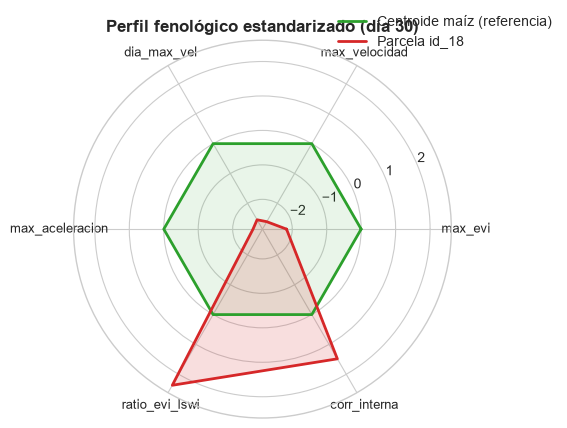

In [52]:
import numpy as np
import matplotlib.pyplot as plt

def graficar_radar_tipicidad(matriz_evi_100, matriz_lswi_100, df_meta_final,
                               indices_maiz, dia_corte=30, id_parcela_caso=None):
    """
    Radar comparando el perfil promedio (z-scored) de maíz confirmado contra
    un caso individual (ej. una parcela no-maíz o la parcela 18 atípica).
    """
    nombres = ["max_evi", "max_velocidad", "dia_max_vel",
               "max_aceleracion", "ratio_evi_lswi", "corr_interna"]

    X = extraer_features_al_dia(matriz_evi_100, matriz_lswi_100, dia_corte=dia_corte)
    X_maiz = X[indices_maiz]
    mu, sigma = X_maiz.mean(axis=0), X_maiz.std(axis=0)

    perfil_maiz = np.zeros(len(nombres))  # el centroide de maíz, en su propia escala, es 0 por definición

    angulos = np.linspace(0, 2 * np.pi, len(nombres), endpoint=False).tolist()
    angulos += angulos[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    valores_maiz = perfil_maiz.tolist() + [perfil_maiz[0]]
    ax.plot(angulos, valores_maiz, color="#2ca02c", linewidth=2, label="Centroide maíz (referencia)")
    ax.fill(angulos, valores_maiz, color="#2ca02c", alpha=0.1)

    if id_parcela_caso is not None:
        idx_caso = df_meta_final[df_meta_final["id_parcela"] == id_parcela_caso].index[0]
        x_caso = (X[idx_caso] - mu) / sigma
        valores_caso = x_caso.tolist() + [x_caso[0]]
        ax.plot(angulos, valores_caso, color="#d62728", linewidth=2,
                label=f"Parcela id_{id_parcela_caso}")
        ax.fill(angulos, valores_caso, color="#d62728", alpha=0.15)

    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(nombres, fontsize=9)
    ax.set_title(f"Perfil fenológico estandarizado (día {dia_corte})", fontsize=12, fontweight="bold")
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.savefig("radar_tipicidad_18.pdf", format="pdf", bbox_inches="tight")
    plt.show()

# Ejemplo: comparar maíz de referencia contra la parcela 18 (caso atípico) o contra un no-maíz (ej. id_21)
graficar_radar_tipicidad(matriz_evi_100, matriz_lswi_100, df_meta_final,
                          indices_maiz_puro, dia_corte=30, id_parcela_caso=18)

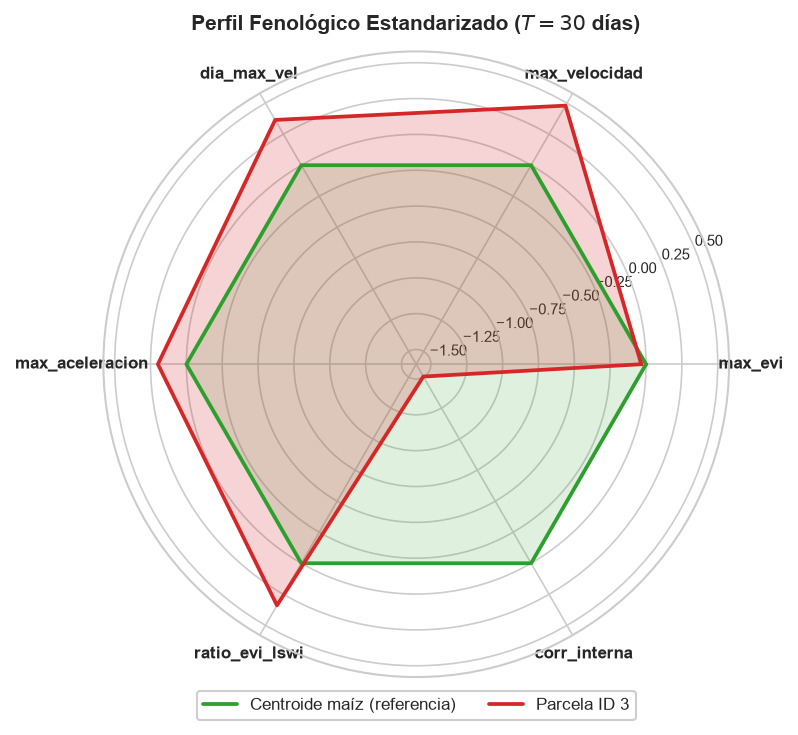

In [72]:
import matplotlib.pyplot as plt
import numpy as np


def graficar_radar_tipicidad(
    matriz_evi_100,
    matriz_lswi_100,
    df_meta_final,
    indices_maiz,
    dia_corte=30,
    id_parcela_caso=None,
):
    """Radar comparando el perfil promedio (z-scored) de maíz confirmado contra

    un caso individual (ej. una parcela no-maíz o la parcela 18 atípica).
    """
    nombres = [
        "max_evi",
        "max_velocidad",
        "dia_max_vel",
        "max_aceleracion",
        "ratio_evi_lswi",
        "corr_interna",
    ]

    X = extraer_features_al_dia(
        matriz_evi_100, matriz_lswi_100, dia_corte=dia_corte
    )
    X_maiz = X[indices_maiz]
    mu, sigma = X_maiz.mean(axis=0), X_maiz.std(axis=0)

    # El centroide de maíz, en su propia escala (z-score), es 0 por definición
    perfil_maiz = np.zeros(len(nombres))

    angulos = np.linspace(0, 2 * np.pi, len(nombres), endpoint=False).tolist()
    angulos += angulos[:1]

    # Ajuste de lienzo compacto en la línea estilística previa
    plt.style.use(
        "seaborn-v0_8-whitegrid"
        if "seaborn-v0_8-whitegrid" in plt.style.available
        else "default"
    )
    fig, ax = plt.subplots(figsize=(5.5, 5.0), dpi=150, subplot_kw=dict(polar=True))

    valores_maiz = perfil_maiz.tolist() + [perfil_maiz[0]]
    ax.plot(
        angulos,
        valores_maiz,
        color="#2ca02c",
        linewidth=1.8,
        label="Centroide maíz (referencia)",
    )
    ax.fill(angulos, valores_maiz, color="#2ca02c", alpha=0.15)

    if id_parcela_caso is not None:
        idx_caso = df_meta_final[
            df_meta_final["id_parcela"] == id_parcela_caso
        ].index[0]
        # Evitar división por cero si la desviación estándar de algún feature fuera 0
        sigma_safe = np.where(sigma == 0, 1e-6, sigma)
        x_caso = (X[idx_caso] - mu) / sigma_safe
        valores_caso = x_caso.tolist() + [x_caso[0]]

        ax.plot(
            angulos,
            valores_caso,
            color="#d62728",
            linewidth=1.8,
            label=f"Parcela ID {id_parcela_caso}",
        )
        ax.fill(angulos, valores_caso, color="#d62728", alpha=0.20)

    # Formato de las etiquetas de los ejes
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(nombres, fontsize=8, fontweight="bold")
    ax.tick_params(axis="y", labelsize=7)

    # Título con relleno superior (pad) para despejar espacio
    ax.set_title(
        f"Perfil Fenológico Estandarizado ($T = {dia_corte}$ días)",
        fontsize=10,
        fontweight="bold",
        pad=10,
    )

    # Leyenda posicíonada abajo al centro (fuera del área polar para no empalmar)
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.009),
        ncol=2,  # Dos columnas para mayor compacidad
        frameon=True,
        facecolor="white",
        framealpha=0.95,
        fontsize=8,
    )

    plt.tight_layout()

    # Exportación a PDF vectorial
    plt.savefig("radar_tipicidad.pdf", format="pdf", bbox_inches="tight")
    plt.show()


# Ejecución de la función
graficar_radar_tipicidad(
    matriz_evi_100,
    matriz_lswi_100,
    df_meta_final,
    indices_maiz_puro,
    dia_corte=30,
    id_parcela_caso=3
)

In [54]:
print(df_meta_final['id_parcela'].unique())

[ 2  3  4  5  6 10 11 18 19 20 21 22 23 24]


In [26]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Crear directorio de salida para gráficos exportables
output_dir = "../reports/figures"
os.makedirs(output_dir, exist_ok=True)

# Estilo global orientado a publicaciones/tesis
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.sans-serif": "DejaVu Sans",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.titlesize": 13,
    "pdf.fonttype": 42,  # TrueType fonts para PDFs editables en Illustrator/Inkscape
    "ps.fonttype": 42
})

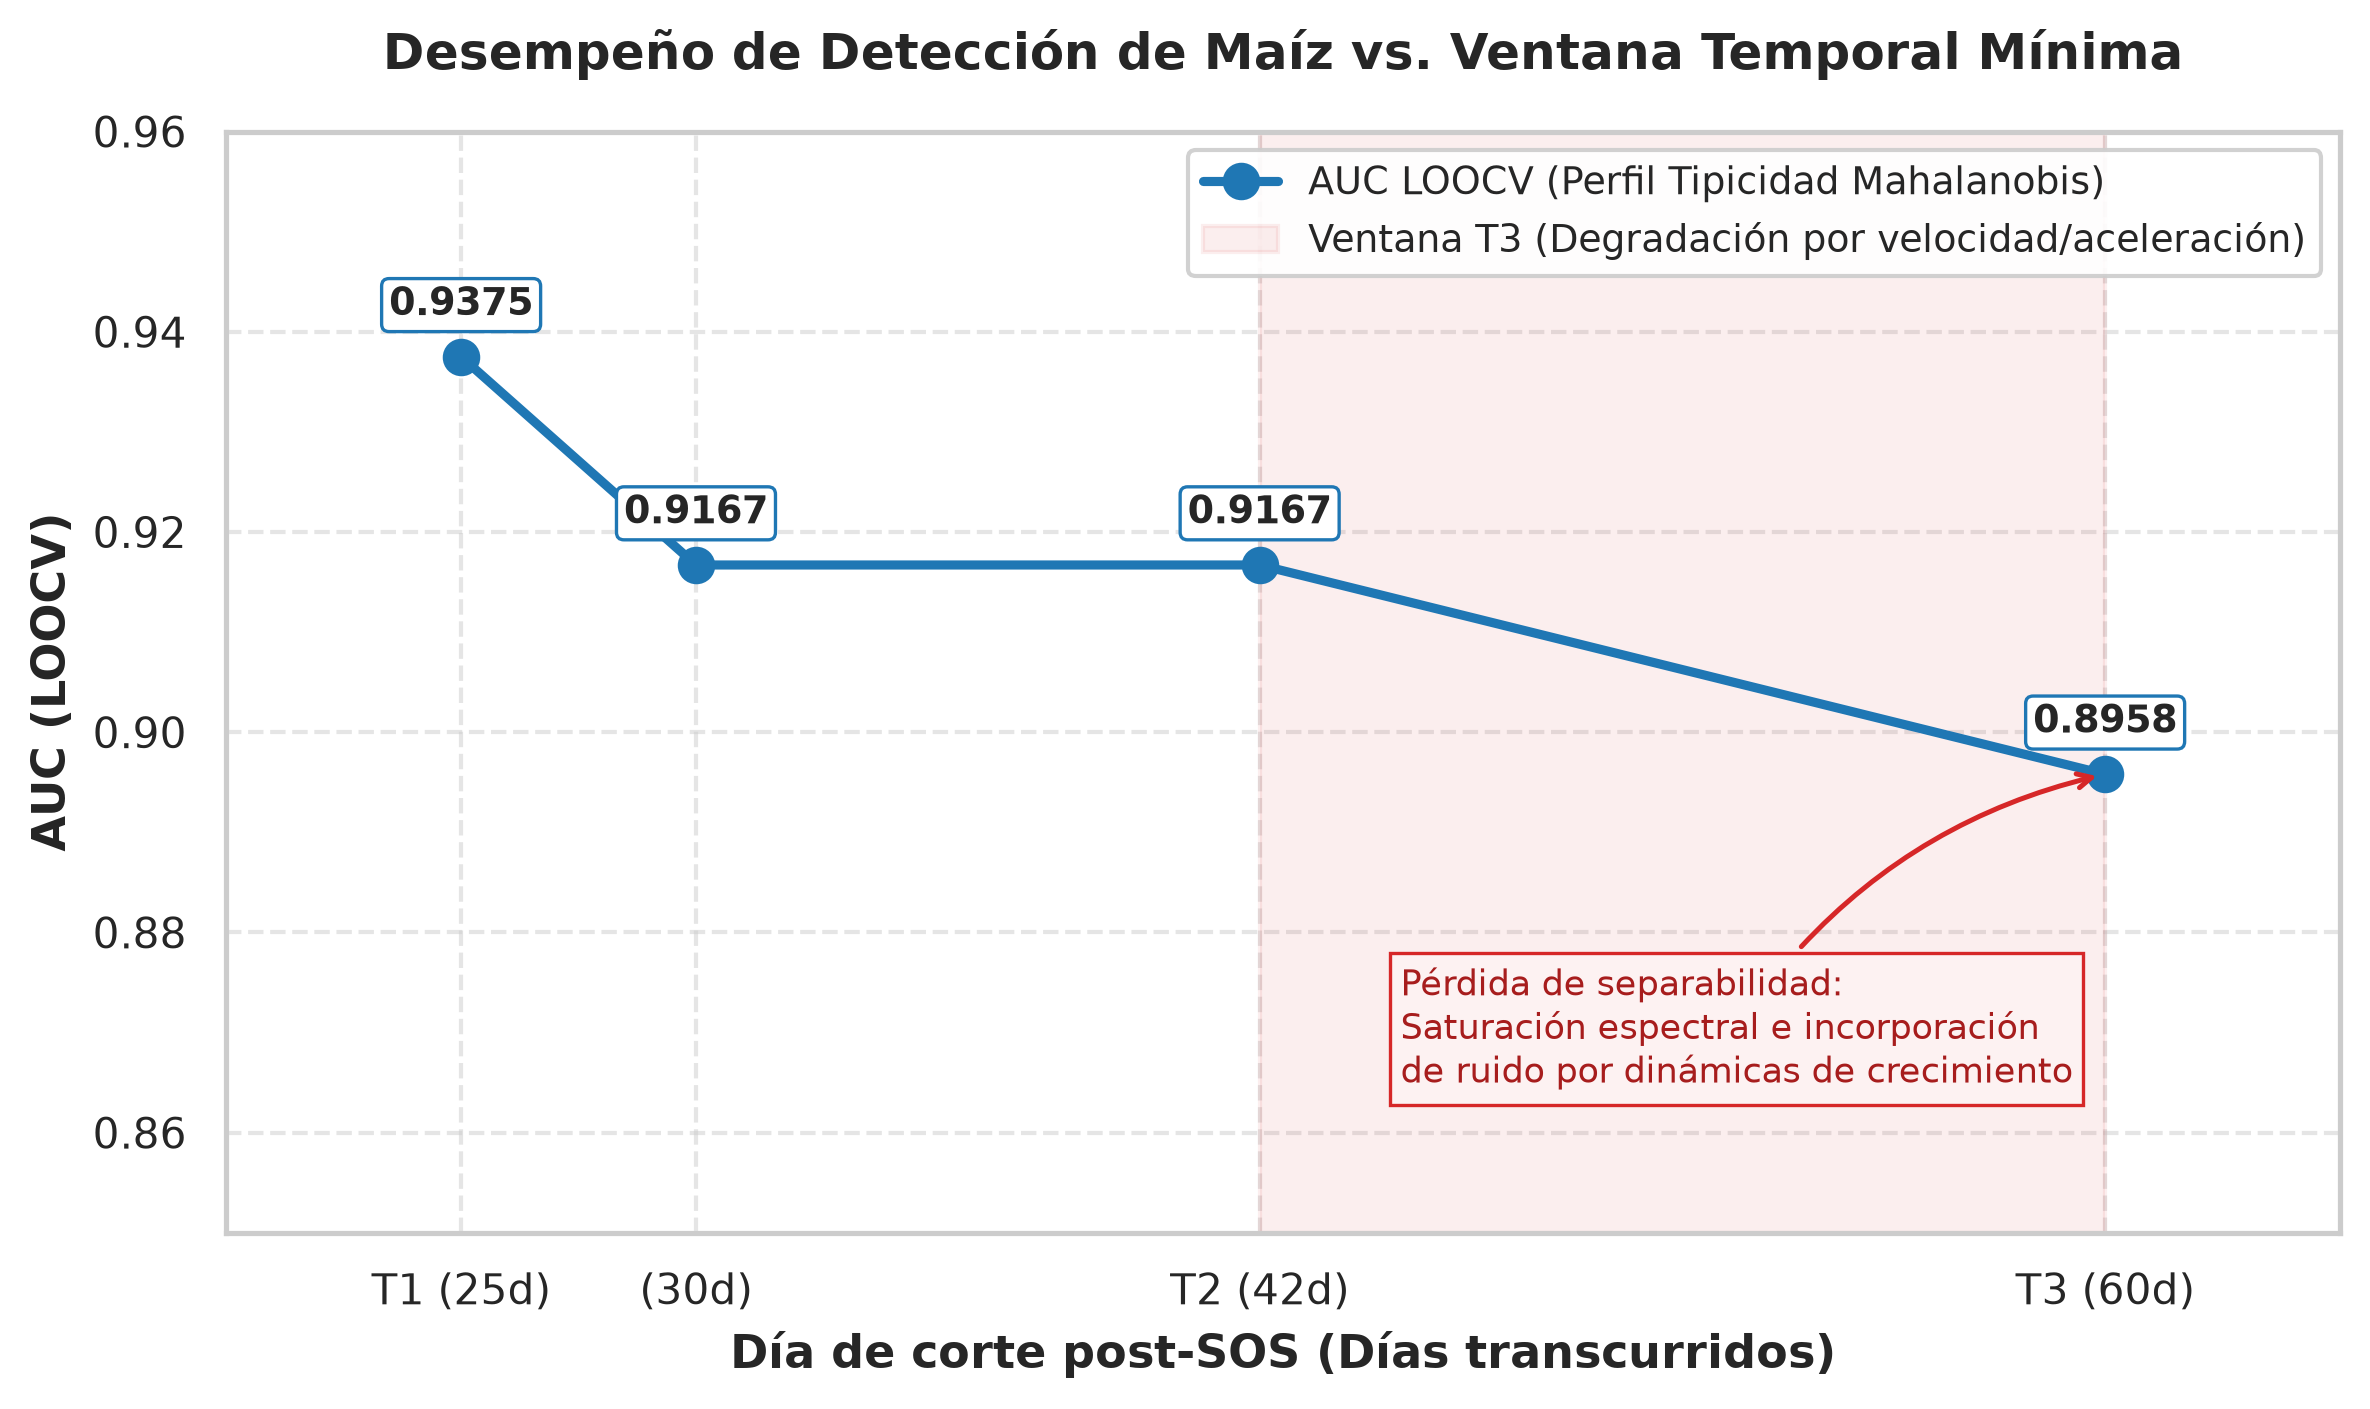

✅ Gráfico exportado correctamente:
 📄 PDF: ../reports/figures\auc_loocv_vs_dia_corte.pdf
 🖼️ PNG: ../reports/figures\auc_loocv_vs_dia_corte.png


In [27]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# 1. Datos del experimento LOOCV
# -----------------------------------------------------------------------------
dias_corte = [25, 30, 42, 60]
auc_loocv = [0.9375, 0.9167, 0.9167, 0.8958]

# -----------------------------------------------------------------------------
# 2. Creación de la figura
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4.8), dpi=300)

# Línea principal y marcadores
ax.plot(
    dias_corte, 
    auc_loocv, 
    marker='o', 
    linewidth=2.2, 
    markersize=8, 
    color='#1f77b4', 
    label='AUC LOOCV (Perfil Tipicidad Mahalanobis)'
)

# Resaltar zona de degradación hacia T3
ax.axvspan(42, 60, color='#d62728', alpha=0.08, label='Ventana T3 (Degradación por velocidad/aceleración)')

# Estilizado y límites de ejes
ax.set_ylim(0.85, 0.96)
ax.set_xlim(20, 65)
ax.set_xticks(dias_corte)
ax.set_xticklabels([f"T1 ({dias_corte[0]}d)", f"({dias_corte[1]}d)", f"T2 ({dias_corte[2]}d)", f"T3 ({dias_corte[3]}d)"])

ax.set_xlabel("Día de corte post-SOS (Días transcurridos)", fontweight='bold')
ax.set_ylabel("AUC (LOOCV)", fontweight='bold')
ax.set_title("Desempeño de Detección de Maíz vs. Ventana Temporal Mínima", pad=15, fontweight='bold')

# -----------------------------------------------------------------------------
# 3. Anotaciones numéricas sobre los puntos
# -----------------------------------------------------------------------------
for x, y in zip(dias_corte, auc_loocv):
    ax.annotate(
        f"{y:.4f}", 
        (x, y), 
        textcoords="offset points", 
        xytext=(0, 10), 
        ha='center', 
        fontsize=9, 
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#1f77b4", lw=0.8)
    )

# Anotación explicativa de hallazgo
ax.annotate(
    "Pérdida de separabilidad:\nSaturación espectral e incorporación\nde ruido por dinámicas de crecimiento",
    xy=(60, 0.8958),
    xytext=(45, 0.865),
    arrowprops=dict(arrowstyle="->", color='#d62728', lw=1.2, connectionstyle="arc3,rad=-0.2"),
    fontsize=8.5,
    color='#a71d1d',
    bbox=dict(boxstyle="square,pad=0.3", fc="#fdf2f2", ec="#d62728", lw=0.8)
)

ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()

# -----------------------------------------------------------------------------
# 4. Exportación en PDF (vectorial) y PNG
# -----------------------------------------------------------------------------
pdf_path = os.path.join(output_dir, "auc_loocv_vs_dia_corte.pdf")
png_path = os.path.join(output_dir, "auc_loocv_vs_dia_corte.png")

plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.savefig(png_path, format="png", bbox_inches="tight", dpi=300)

plt.show()
print(f"✅ Gráfico exportado correctamente:\n 📄 PDF: {pdf_path}\n 🖼️ PNG: {png_path}")

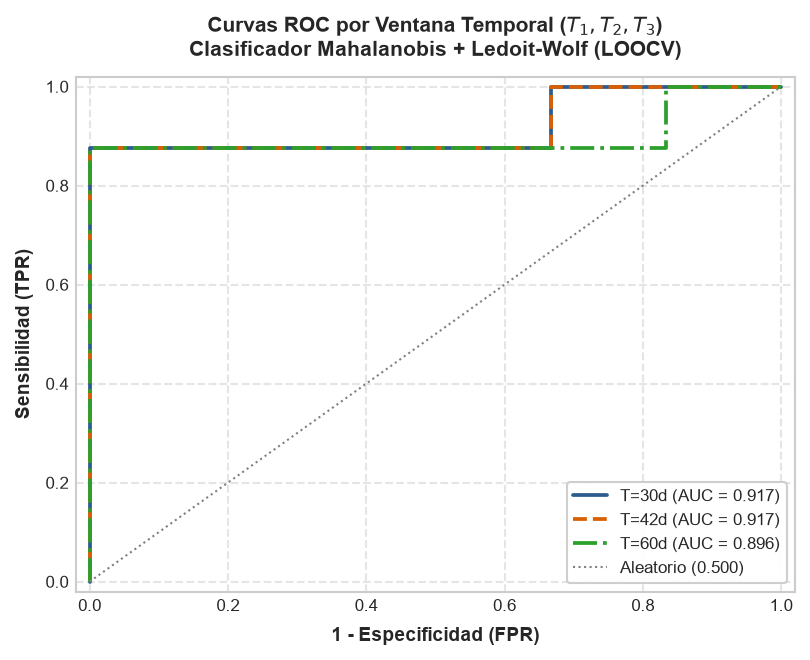

In [52]:
# ==============================================================================
# CELDA — CURVAS ROC POR VENTANA TEMPORAL (T1 / T2 / T3) [MAHALANOBIS LEDOIT-WOLF]
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import auc, roc_curve

# Configuración de estilo
plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)

# Tamaños y proporciones ajustados para figura compacta de ~5x4.5 pulgadas
plt.figure(figsize=(5.5, 4.5), dpi=150)

ventanas = [30, 42, 60]
colores = ["#2b5c8f", "#d95f02", "#2ca02c"]
estilos_linea = ["-", "--", "-."]

# Bucle sobre las ventanas operativas (T1=30, T2=42, T3=60)
for i, t in enumerate(ventanas):
    # Usamos tus variables de entrada exactas: indices_maiz_puro e indices_no_maiz
    auc_score, df_detalle = loocv_auc_ledoit(
        dia_corte=t,
        indices_maiz=indices_maiz_puro,
        indices_no_maiz=indices_no_maiz,
    )

    y_true = df_detalle["es_maiz_real"].astype(int)
    # Como tu función ya calcula score = -dist en y_score internamente,
    # en df_detalle tenemos la distancia directa; la invertimos para el ordenamiento de roc_curve
    y_score = -df_detalle["distancia_mahalanobis"]

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc_calc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        color=colores[i],
        linestyle=estilos_linea[i],
        linewidth=1.8,
        label=f"T={t}d (AUC = {roc_auc_calc:.3f})",
    )

# Diagonal de azar
plt.plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle=":",
    linewidth=1.0,
    label="Aleatorio (0.500)",
)

# Ajustes estéticos de ejes y fuentes
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.xlabel("1 - Especificidad (FPR)", fontsize=9, fontweight="bold", labelpad=6)
plt.ylabel("Sensibilidad (TPR)", fontsize=9, fontweight="bold", labelpad=6)
plt.title(
    "Curvas ROC por Ventana Temporal ($T_1, T_2, T_3$)\nClasificador Mahalanobis + Ledoit-Wolf (LOOCV)",
    fontsize=10,
    fontweight="bold",
    pad=10,
)

plt.legend(
    loc="lower right",
    frameon=True,
    facecolor="white",
    framealpha=0.95,
    fontsize=8,
)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

plt.savefig("curvas_roc_mahalanobis_ledoit.pdf", format="pdf", bbox_inches="tight")

plt.show()

C:\Users\mayno\AppData\Local\Temp\ipykernel_23060\4056542795.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\mayno\AppData\Local\Temp\ipykernel_23060\4056542795.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


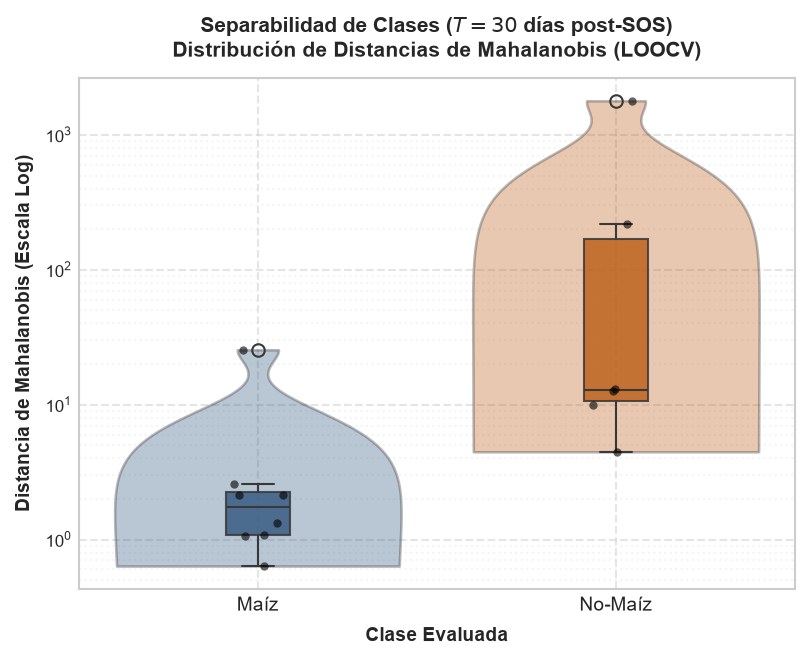

In [53]:
# ==============================================================================
# CELDA — VIOLINPLOT/BOXPLOT DE DISTANCIAS MAHALANOBIS POR CLASE (ESCALA LOG)
# ==============================================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# 1. Preparar/Asegurar datos de la ventana (ejemplo T = 30 días)
# Si ya ejecutas loocv_auc_ledoit para T=30:
_, df_detalle_t30 = loocv_auc_ledoit(
    dia_corte=30,
    indices_maiz=indices_maiz_puro,
    indices_no_maiz=indices_no_maiz,
)

# Creamos una etiqueta clara para el eje X
df_detalle_t30["Clase"] = df_detalle_t30["es_maiz_real"].map(
    {True: "Maíz", False: "No-Maíz"}
)

# 2. Configuración de figura y estilo
plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)
fig, ax = plt.subplots(figsize=(5.5, 4.5), dpi=150)

paleta = {"Maíz": "#2b5c8f", "No-Maíz": "#d95f02"}

# 3. Dibujar Violinplot (distribución suave) + Boxplot interno (cuartiles)
sns.violinplot(
    data=df_detalle_t30,
    x="Clase",
    y="distancia_mahalanobis",
    palette=paleta,
    inner=None,  # Quitamos el boxplot interno por defecto de seaborn para personalizarlo
    cut=0,
    alpha=0.35,
    ax=ax,
)

sns.boxplot(
    data=df_detalle_t30,
    x="Clase",
    y="distancia_mahalanobis",
    palette=paleta,
    width=0.18,
    boxprops=dict(alpha=0.85),
    showcaps=True,
    ax=ax,
)

# Agregar jitter de puntos (stripchart) para ver la N exacta de parcelas
sns.stripplot(
    data=df_detalle_t30,
    x="Clase",
    y="distancia_mahalanobis",
    color="black",
    alpha=0.6,
    jitter=0.08,
    size=4,
    ax=ax,
)

# 4. Escala logarítmica en Eje Y para evitar el aplastamiento
ax.set_yscale("log")

# Formato limpio para marcas de log (ej. 10^0, 10^1, 10^2, 10^3)
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))
ax.yaxis.set_minor_locator(
    ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10)
)

# 5. Formato de ejes, tipografías y títulos
ax.tick_params(axis="x", labelsize=9)
ax.tick_params(axis="y", labelsize=8, which="both")

ax.set_xlabel("Clase Evaluada", fontsize=9, fontweight="bold", labelpad=6)
ax.set_ylabel(
    "Distancia de Mahalanobis (Escala Log)",
    fontsize=9,
    fontweight="bold",
    labelpad=6,
)
ax.set_title(
    "Separabilidad de Clases ($T = 30$ días post-SOS)\nDistribución de Distancias de Mahalanobis (LOOCV)",
    fontsize=10,
    fontweight="bold",
    pad=10,
)

ax.grid(True, which="major", linestyle="--", alpha=0.5)
ax.grid(True, which="minor", linestyle=":", alpha=0.2)
plt.tight_layout()

# 6. Exportación a PDF vectorial
plt.savefig(
    "distancia_mahalanobis_boxplot_t30.pdf", format="pdf", bbox_inches="tight"
)

plt.show()

In [56]:
import pandas as pd
import numpy as np

def resumen_por_clase(df, col="distancia_mahalanobis", clase_col="Clase"):
    filas = []
    for clase, g in df.groupby(clase_col):
        s = g[col].dropna()
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lim_inf = q1 - 1.5 * iqr
        lim_sup = q3 + 1.5 * iqr
        filas.append({
            "Clase": clase,
            "n": len(s),
            "min": s.min(),
            "Q1": q1,
            "median": s.median(),
            "Q3": q3,
            "IQR": iqr,
            "lim_inf": lim_inf,
            "lim_sup": lim_sup,
            "outliers_inf": s[s < lim_inf].tolist(),
            "outliers_sup": s[s > lim_sup].tolist()
        })
    return pd.DataFrame(filas).set_index("Clase")

print(resumen_por_clase(df_detalle_t30, col="distancia_mahalanobis", clase_col="Clase"))


         n       min         Q1     median          Q3         IQR  \
Clase                                                                
Maíz     8  0.635927   1.075257   1.728451    2.253072    1.177815   
No-Maíz  6  4.473883  10.668434  12.810126  168.549830  157.881396   

            lim_inf     lim_sup outliers_inf          outliers_sup  
Clase                                                               
Maíz      -0.691465    4.019794           []    [25.5246138295888]  
No-Maíz -226.153659  405.371924           []  [1791.0919081953339]  


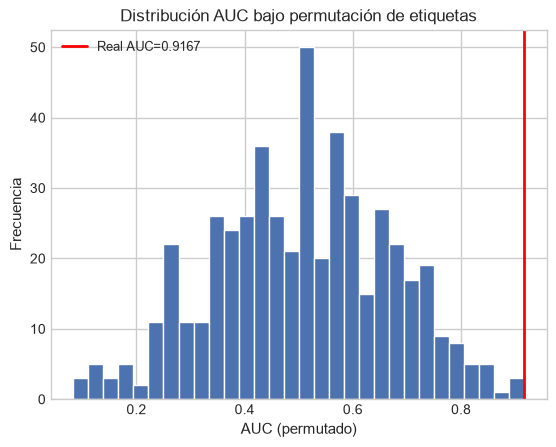

In [62]:
import matplotlib.pyplot as plt
plt.hist(perm_aucs, bins=30, alpha=1)
plt.axvline(real_auc, color='red', lw=2, label=f"Real AUC={real_auc:.4f}")
plt.xlabel("AUC (permutado)")
plt.ylabel("Frecuencia")
plt.title("Distribución AUC bajo permutación de etiquetas")
plt.legend()
plt.savefig("prueba_permutacion_auc.pdf", format="pdf", bbox_inches="tight")
plt.show()